In [99]:
# Imports essential Libraries
import pandas as pd
import numpy as np
import sys
import gc
import random
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import xgboost as xgb
import tensorflow as tf
import os, warnings, logging

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from tensorflow.keras import layers, models, callbacks, optimizers, metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, precision_score, confusion_matrix, recall_score, f1_score
from sklearn.model_selection import learning_curve

# Load dataset 
df = pd.read_csv("Final_Synthetic dataset.csv")

In [101]:
# Global setup
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Exploratory Data Analysis (EDA)

In [104]:
# 1.1 Basic Inspection
# 1.2 Data Types and missing values analysis
# 1.3 Duplicate value analysis
# 1.4 Class Balance Check
# 1.5 Summary Statistics
# 1.6 Univariate Analysis - Histograms and box plots for numerical features
# 1.7 Multivariate Analysis - Correlation Heatmap
# 1.8 Time column inspection
# 1.9 Feature trends over time (Sepsis(1) vs Non-Sepsis(0))
# 1.10 PCA visualization

In [106]:
# 1.1 Basic inspection
print("Shape of dataset:", df.shape)
print("Data types:", df.dtypes)
print("Column names:", df.columns.tolist())
print("First 5 rows:", df.head())

# 1.2 Data types and missing values
print("Information about dataset:")
print(df.info())
print("Missing values per column:", df.isnull().sum())

#1.3 Duplicate values
print("Duplicate data:")
print(df.duplicated().sum())

Shape of dataset: (250000, 15)
Data types: subject_id                    int64
icustay_id                  float64
hour                          int64
sepsis_label                  int64
FiO2                        float64
GCS                           int64
MAP                         float64
Bilirubin                   float64
Creatinine                  float64
PaO2                        float64
Platelets                   float64
dobutamine                  float64
dopamine                    float64
norepinephrine              float64
suspected_infection_flag      int64
dtype: object
Column names: ['subject_id', 'icustay_id', 'hour', 'sepsis_label', 'FiO2', 'GCS', 'MAP', 'Bilirubin', 'Creatinine', 'PaO2', 'Platelets', 'dobutamine', 'dopamine', 'norepinephrine', 'suspected_infection_flag']
First 5 rows:    subject_id  icustay_id  hour  sepsis_label      FiO2  GCS        MAP  \
0       20000  307814.647     0             1  0.548874    3  75.574750   
1       20000  307814.647     

Class distribution: sepsis_label
1    125000
0    125000
Name: count, dtype: int64


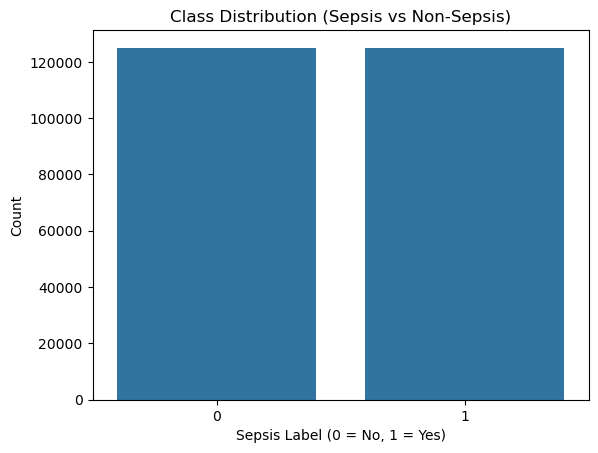

In [108]:
# 1.4 Class balance check
print("Class distribution:", df['sepsis_label'].value_counts())
sns.countplot(x='sepsis_label', data=df)
plt.title("Class Distribution (Sepsis vs Non-Sepsis)")
plt.xlabel("Sepsis Label (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [110]:
# 1.5 Summary statistics for features
print("Descriptive statistics:", df.describe().T)

Descriptive statistics:                              count           mean          std            min  \
subject_id                250000.0   24999.500000  2886.757105   20000.000000   
icustay_id                250000.0  306386.441500  1428.208356  304958.236000   
hour                      250000.0      12.000000     7.211117       0.000000   
sepsis_label              250000.0       0.500000     0.500001       0.000000   
FiO2                      250000.0       0.560701     0.093246       0.347245   
GCS                       250000.0       8.126808     4.235054       3.000000   
MAP                       250000.0      76.363349    10.806860      44.809214   
Bilirubin                 250000.0       2.593688     3.477026       0.000000   
Creatinine                250000.0       1.318466     1.033915       0.000000   
PaO2                      250000.0     132.047141    71.163597      30.000000   
Platelets                 250000.0     225.311551    99.969034       0.000000   
dobu

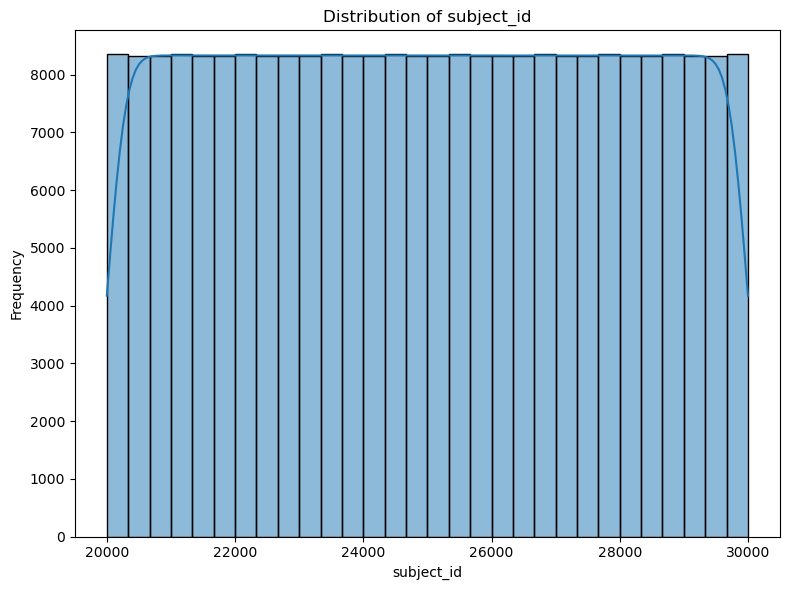

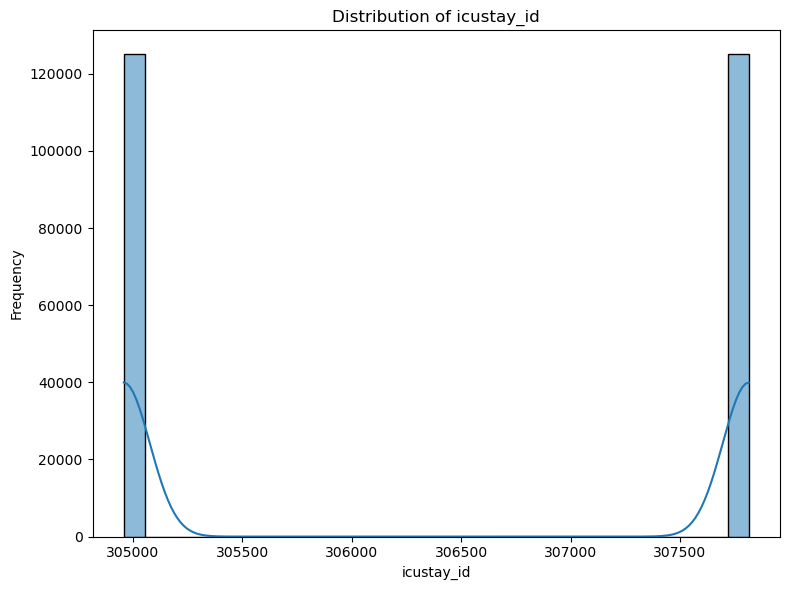

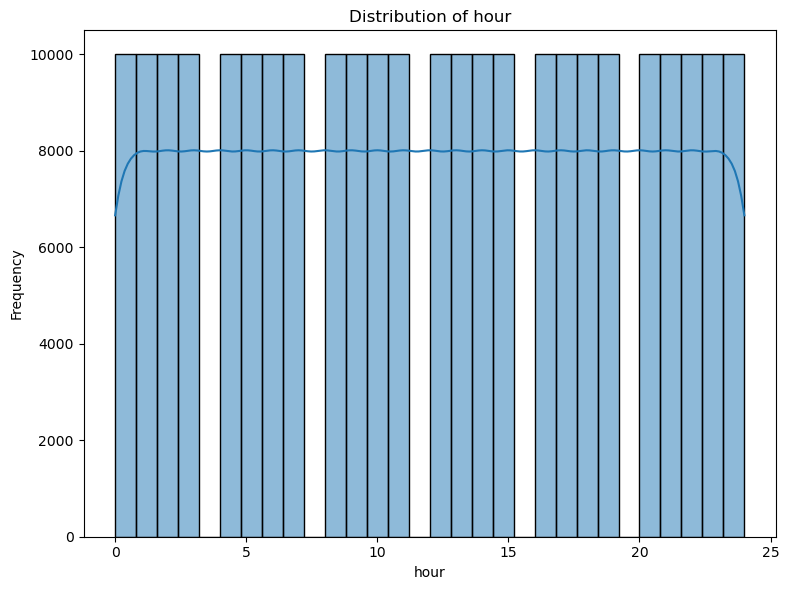

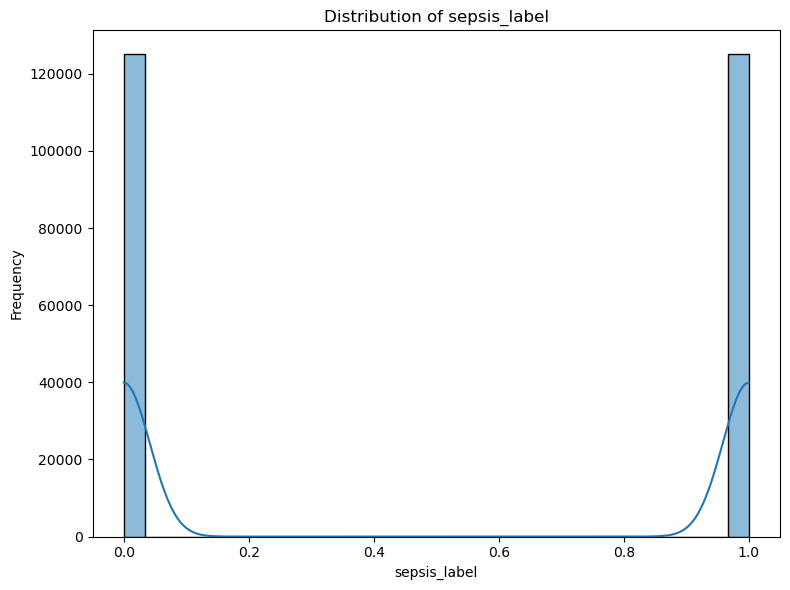

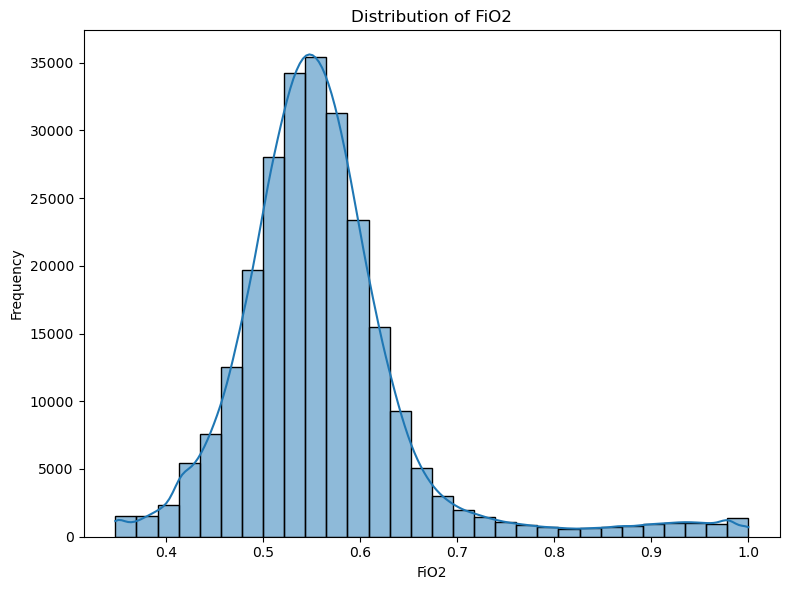

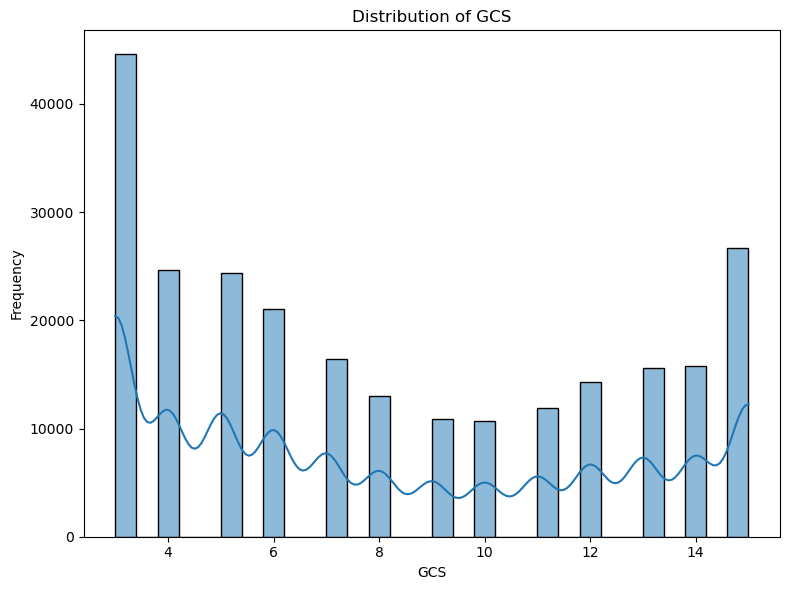

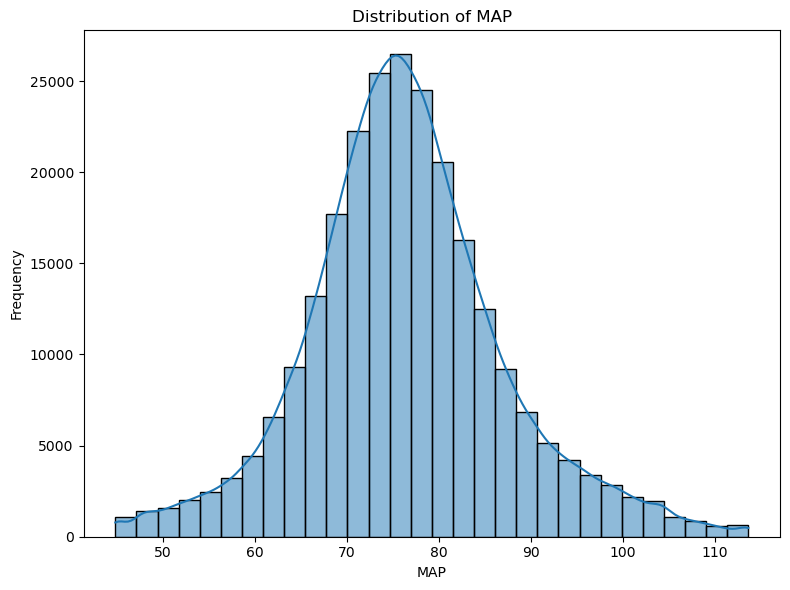

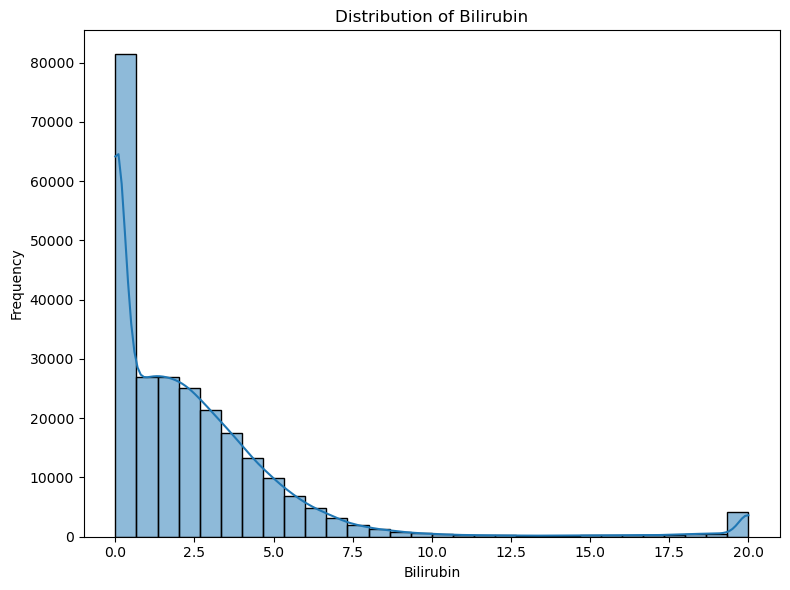

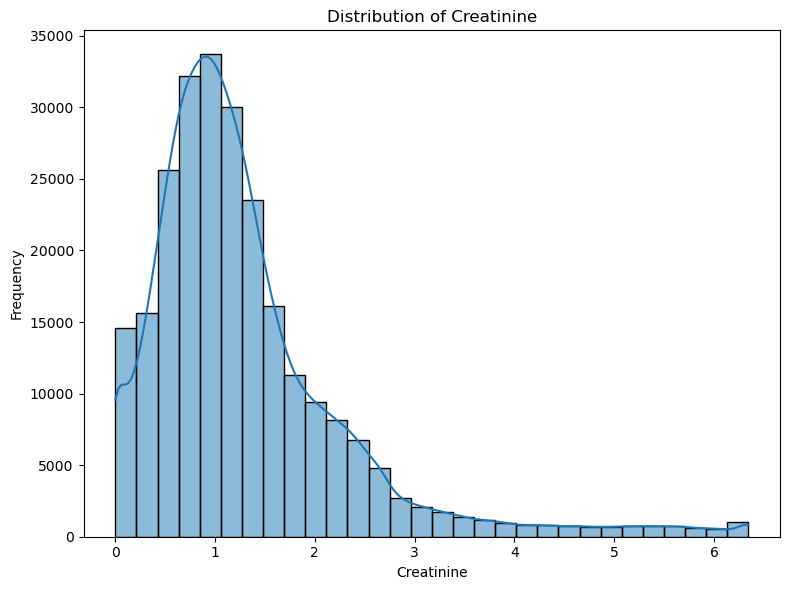

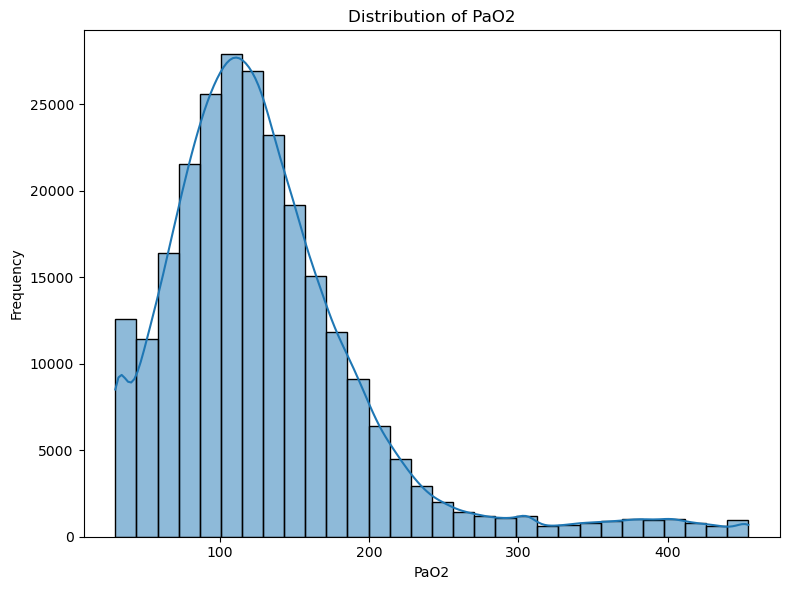

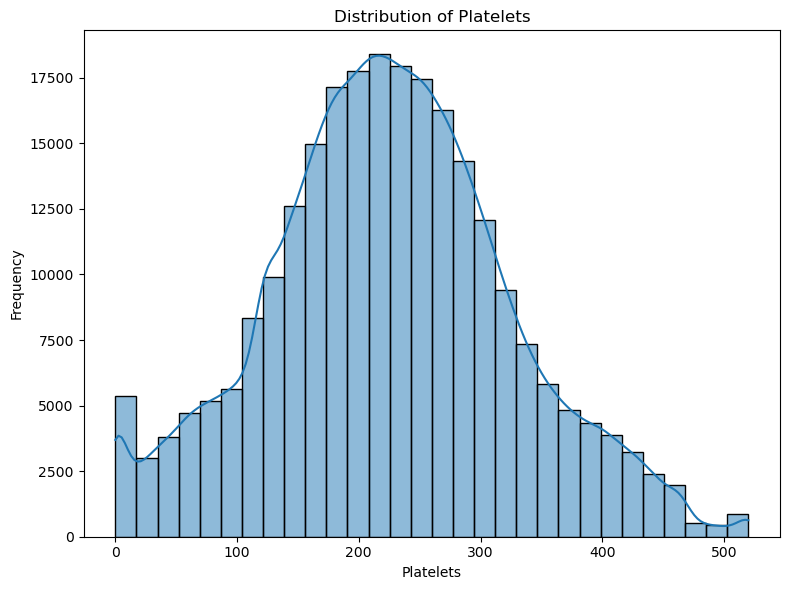

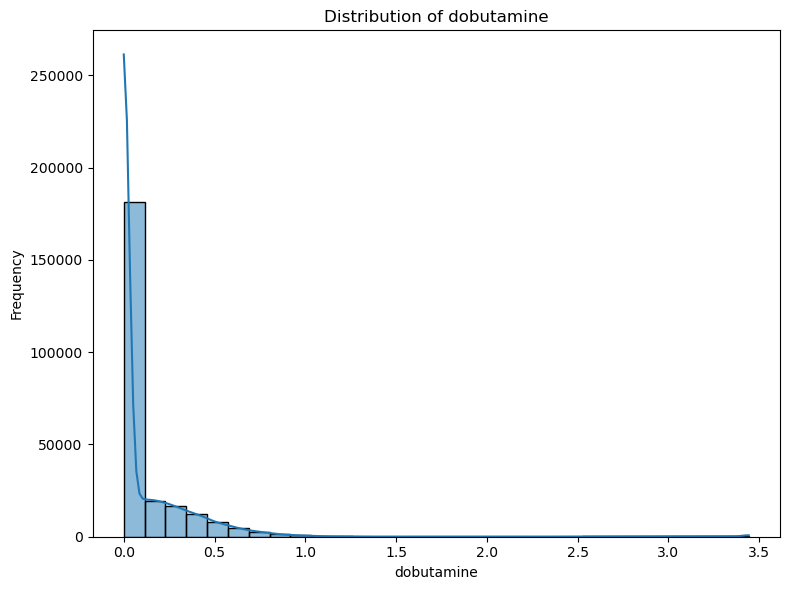

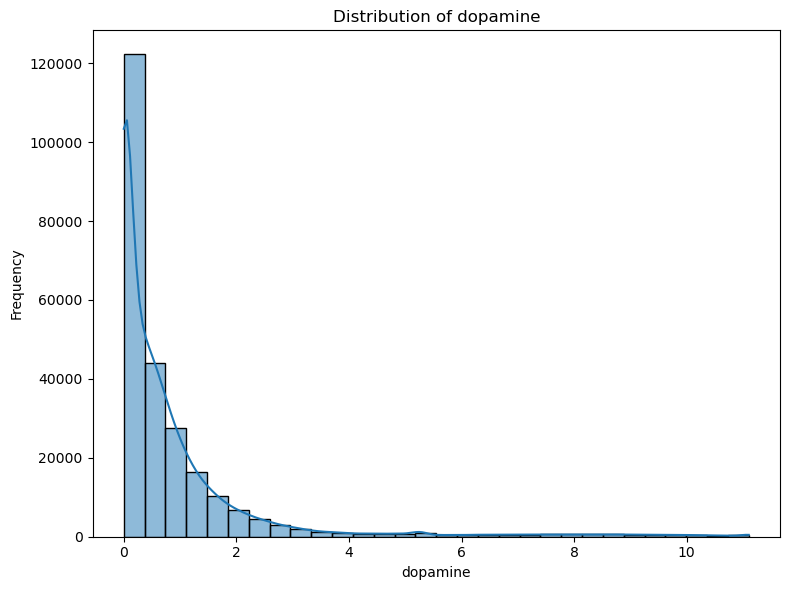

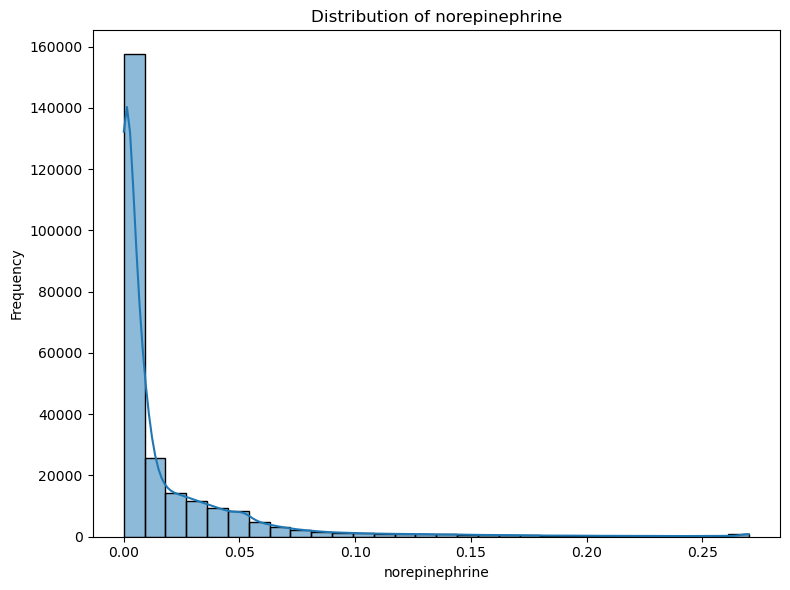

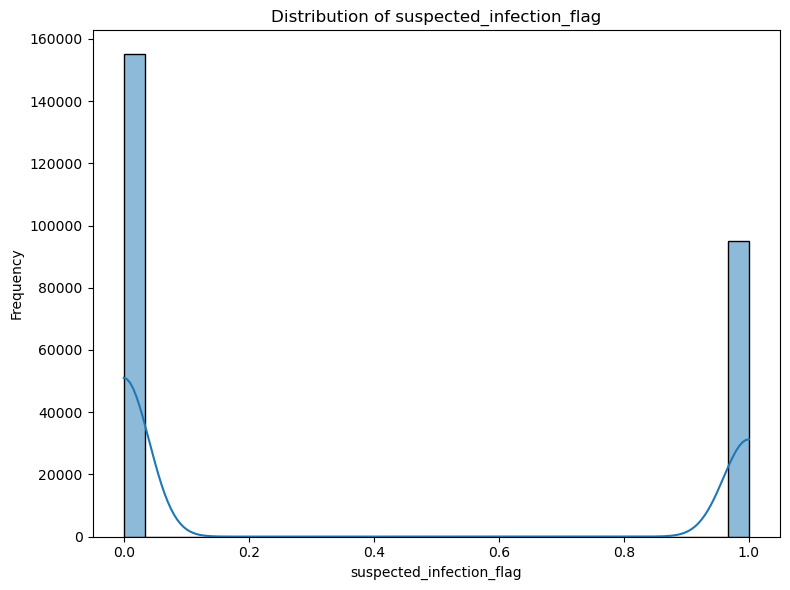

---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------


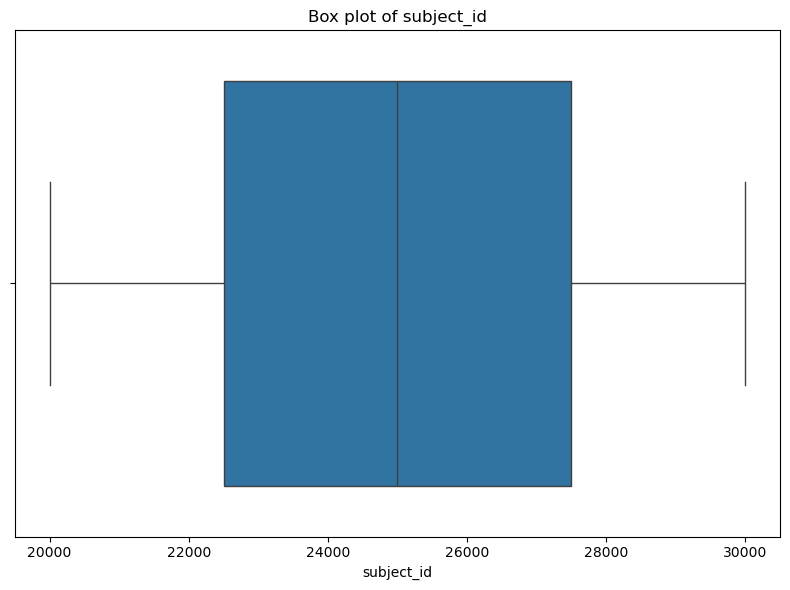

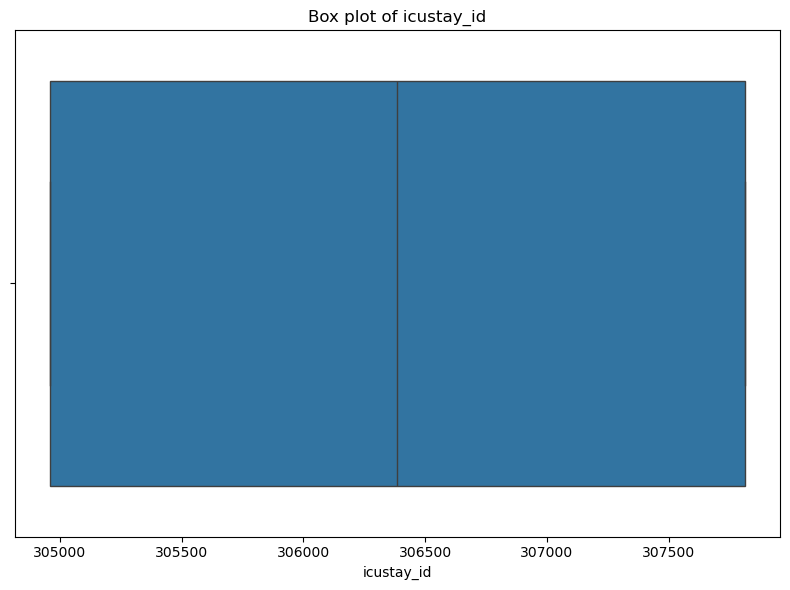

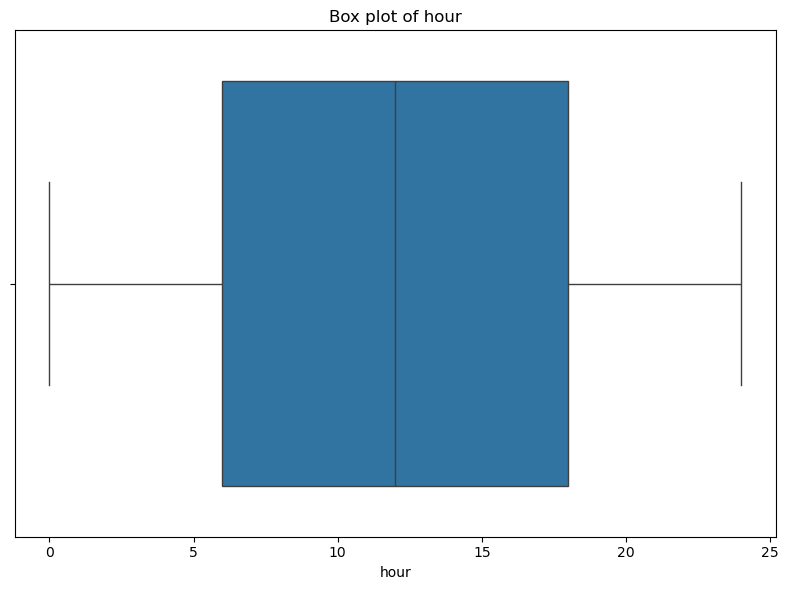

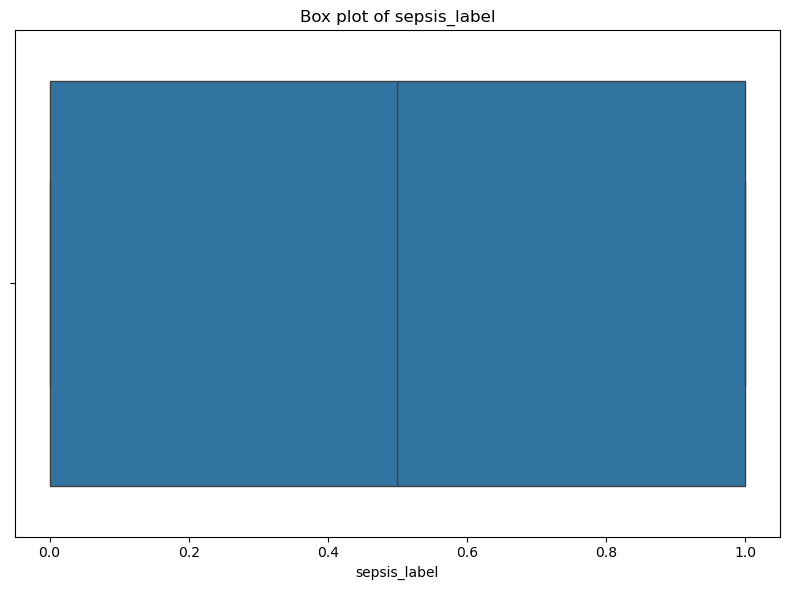

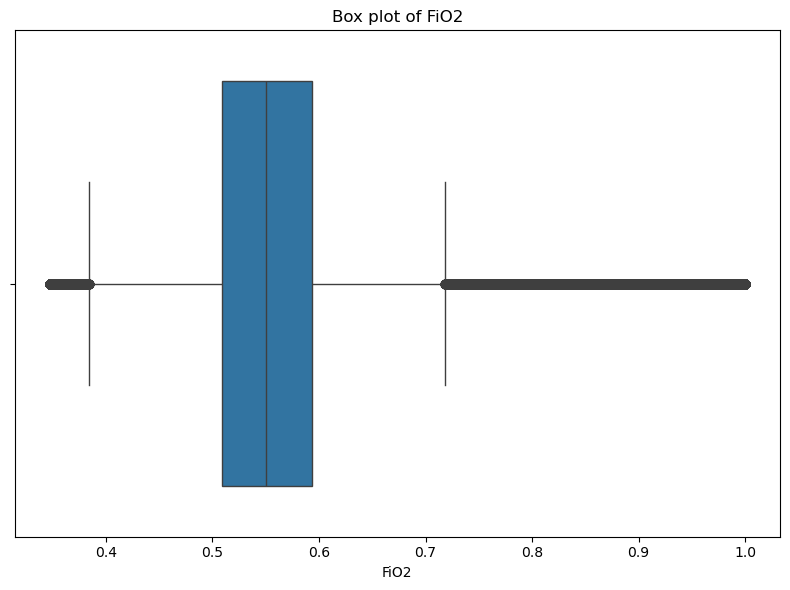

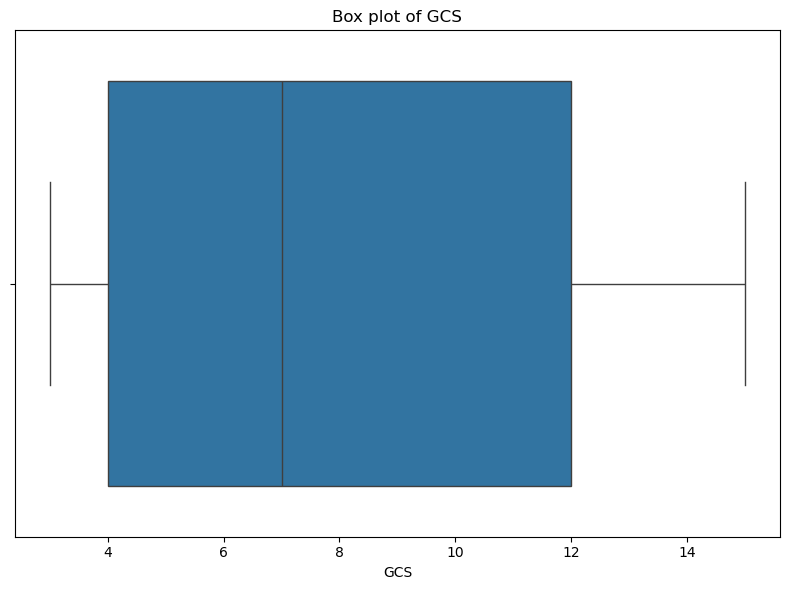

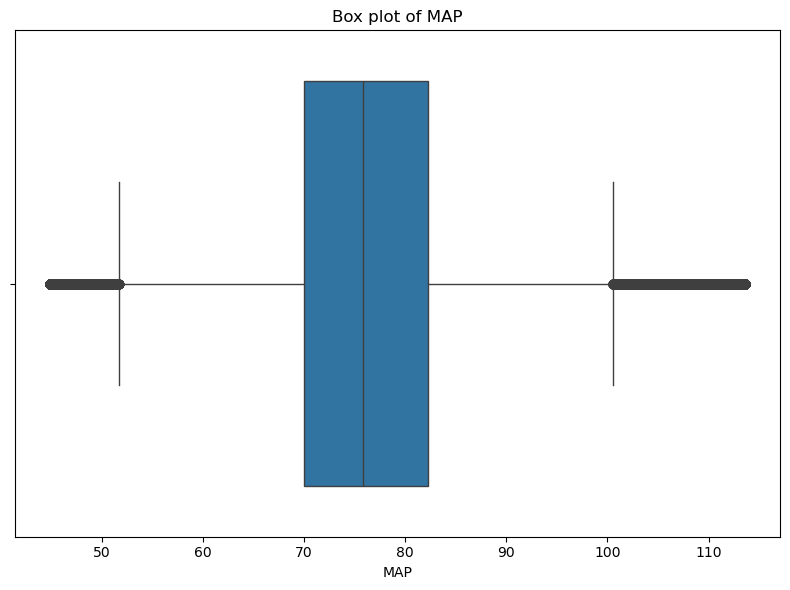

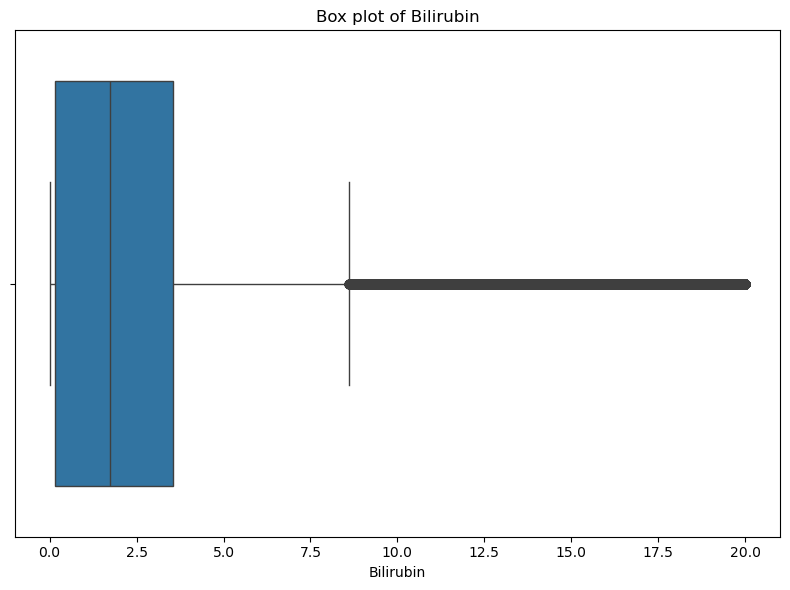

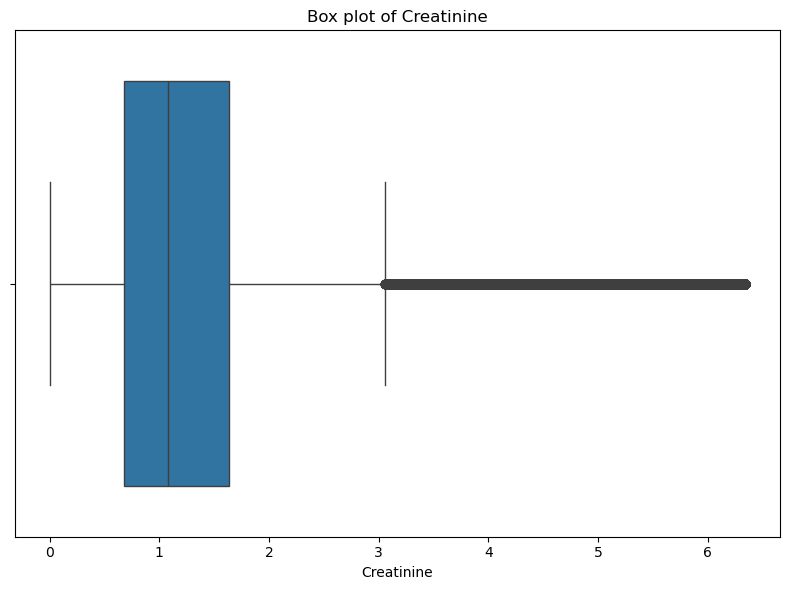

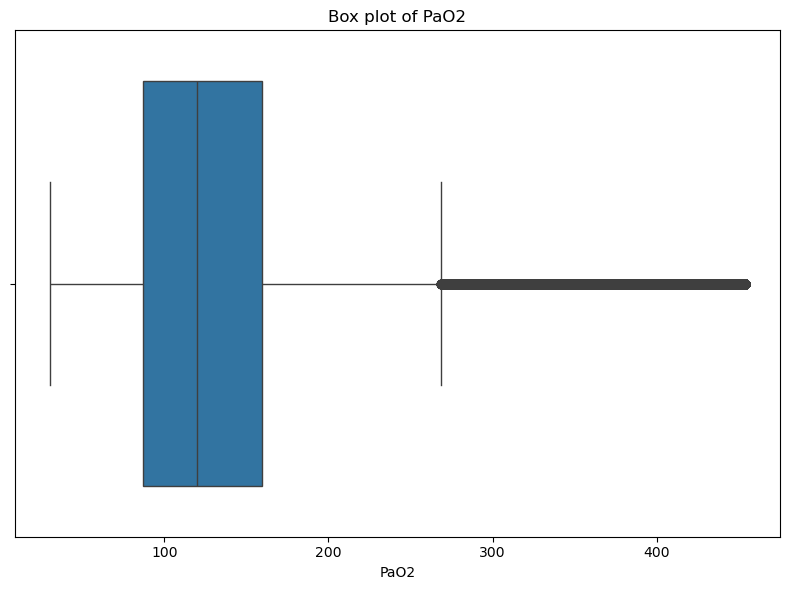

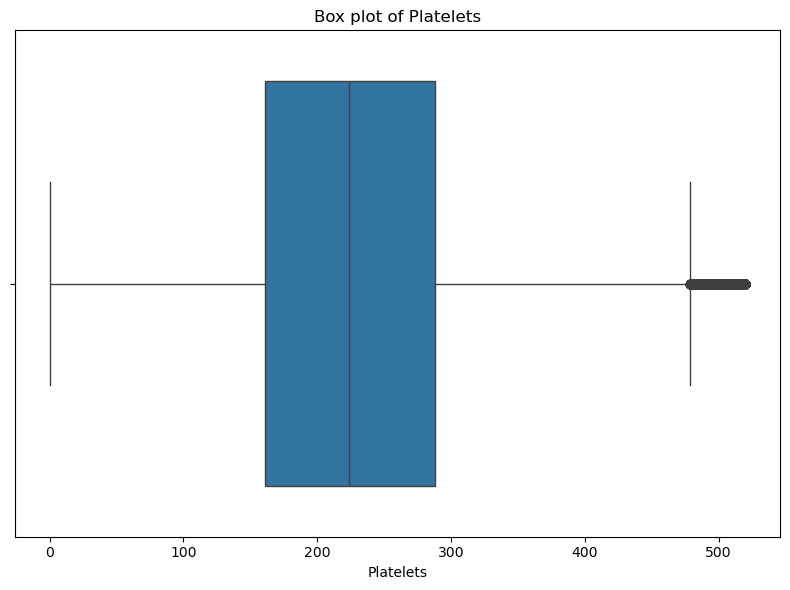

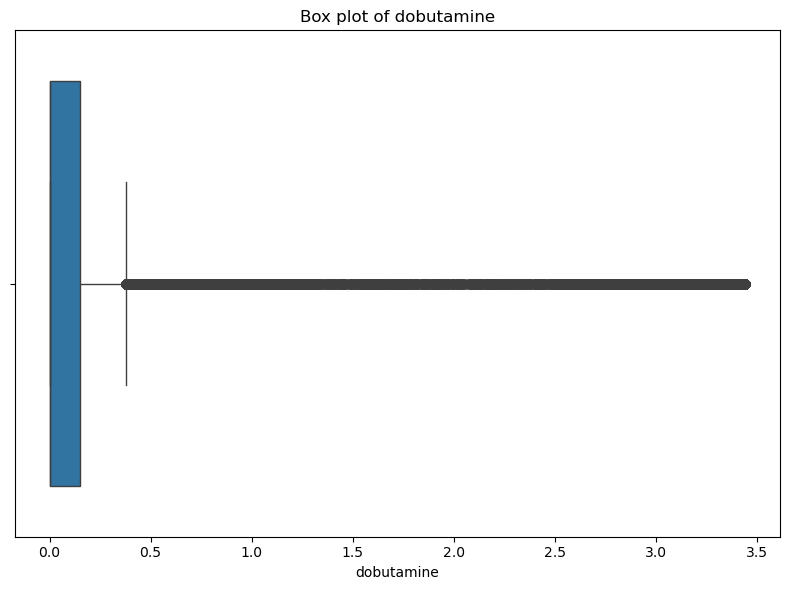

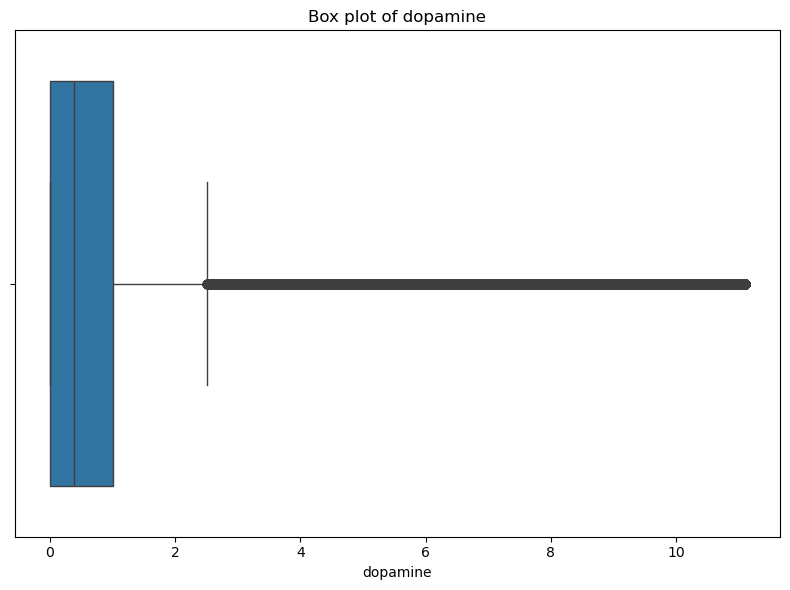

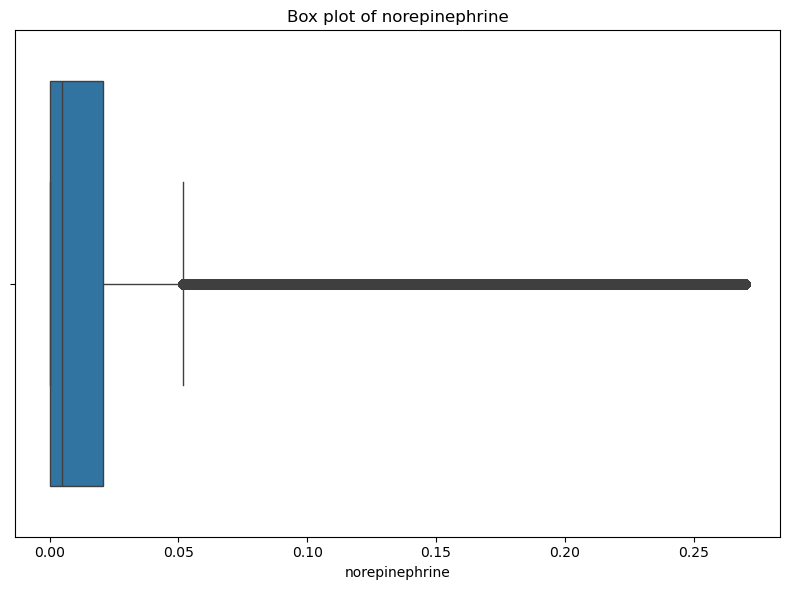

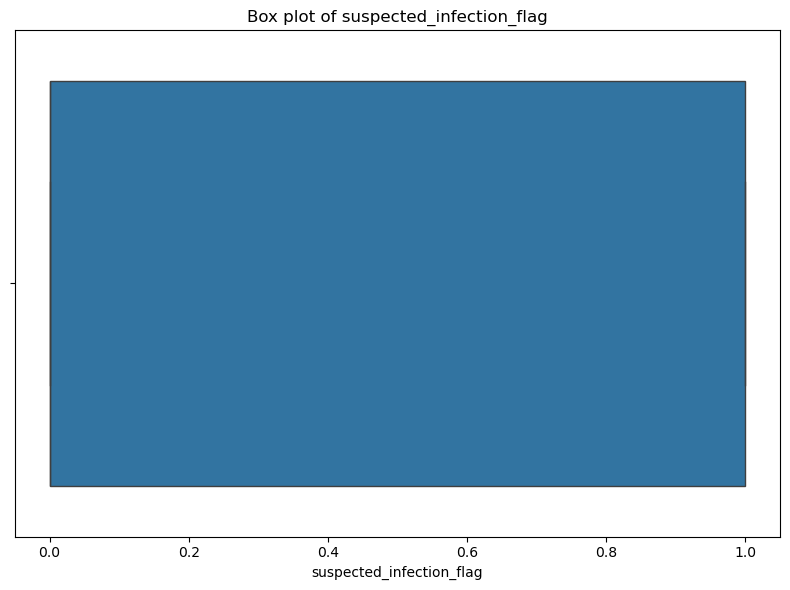

In [112]:
# 1.6 Univariate analysis
# Histograms for the distributions
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print("---------------------------------------------------------------------------------------")
print("---------------------------------------------------------------------------------------")

#  Box plots for numeric columns
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

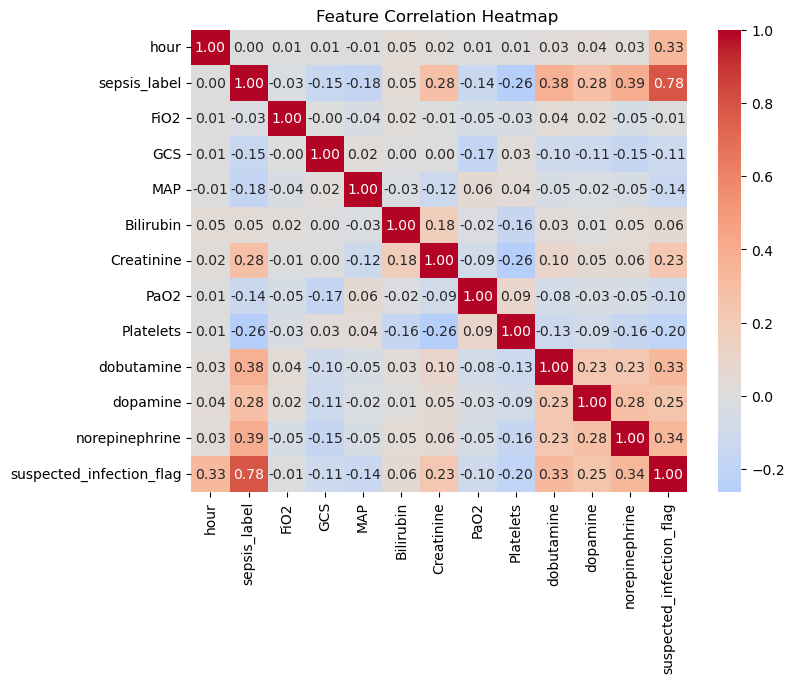

In [18]:
# 1.7 Multivariate analysis - Correlation heatmap for feature variables
# Exclude ID columns
exclude_cols = ['subject_id', 'icustay_id']
corr_cols = [c for c in numerical_cols if c not in exclude_cols]

# Plot correlation heatmap using only the selected columns
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap ")
plt.show()

In [24]:
# 1.8 Time column inspection
# Inspect timeline using subject_id
sample_subject = df['subject_id'].unique()[0]
df_sample = df[df['subject_id'] == sample_subject].sort_values('hour')

print(f"Time sequence for subject {sample_subject}:", df_sample.head(10))

Time sequence for subject 20000:    subject_id  icustay_id  hour  sepsis_label      FiO2  GCS        MAP  \
0       20000  307814.647     0             1  0.548874    3  75.574750   
1       20000  307814.647     1             1  0.573940    4  76.706812   
2       20000  307814.647     2             1  0.557325    3  76.390655   
3       20000  307814.647     3             1  0.500703    3  80.001086   
4       20000  307814.647     4             1  0.548704    3  81.595727   
5       20000  307814.647     5             1  0.600466    5  75.052370   
6       20000  307814.647     6             1  0.540844    6  73.494387   
7       20000  307814.647     7             1  0.513510    6  69.312378   
8       20000  307814.647     8             1  0.545042    4  72.747054   
9       20000  307814.647     9             1  0.549372    5  71.207585   

   Bilirubin  Creatinine        PaO2   Platelets  dobutamine  dopamine  \
0   0.953432    1.733104  270.890940  474.589544    0.000000  1.023

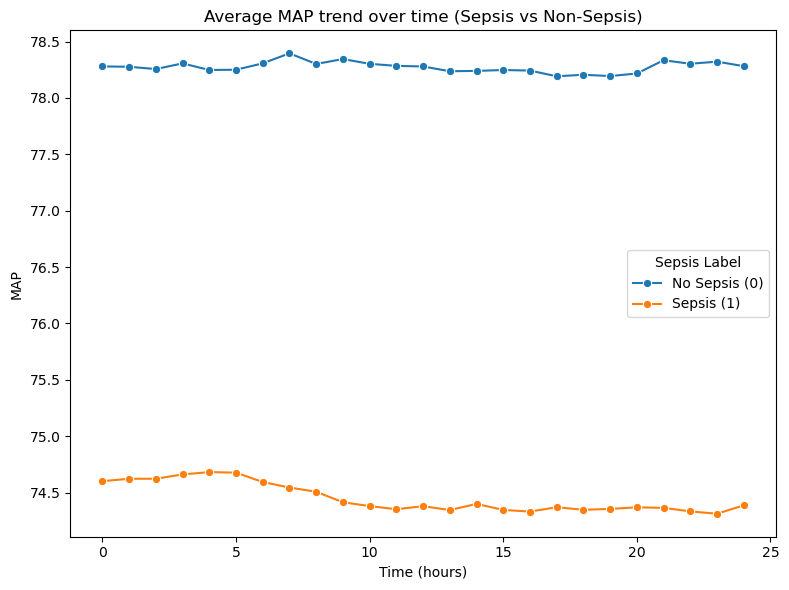

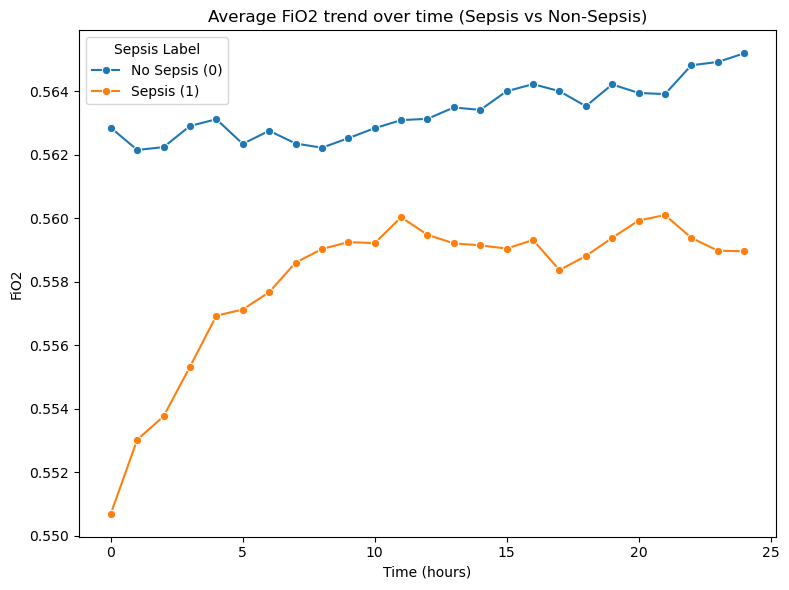

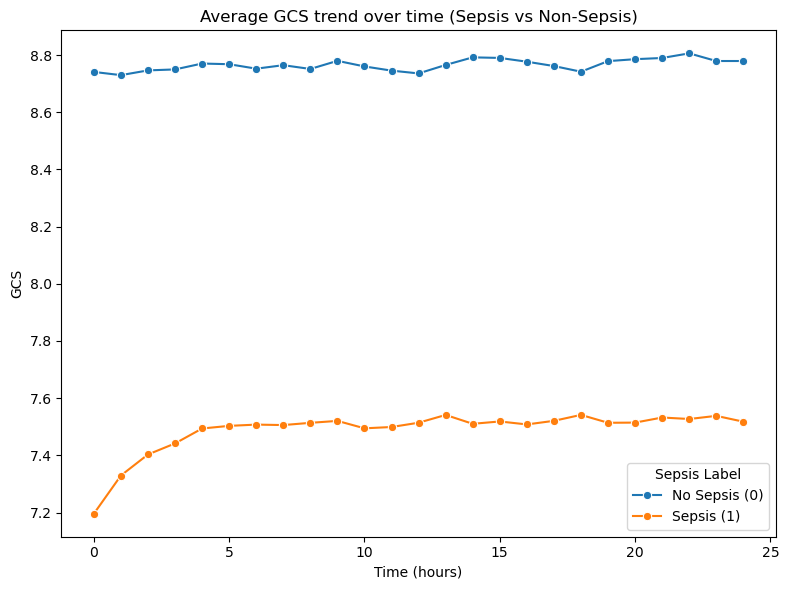

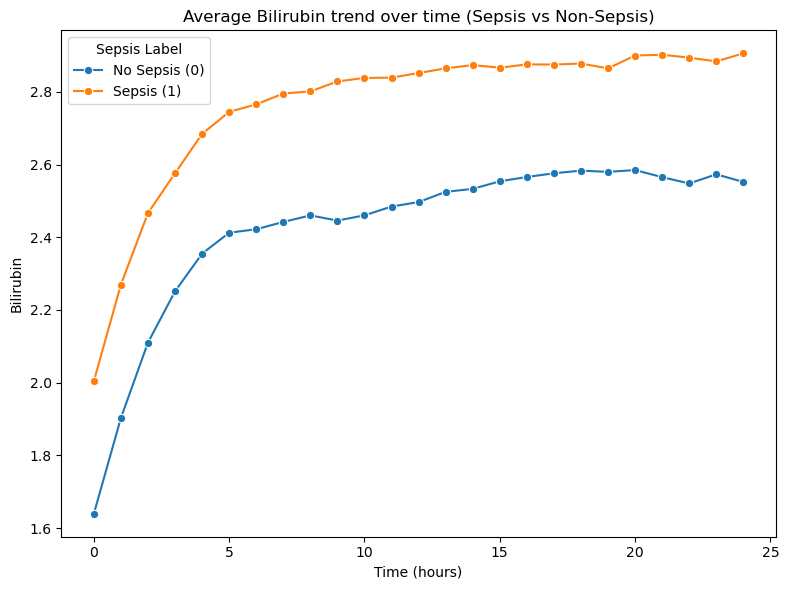

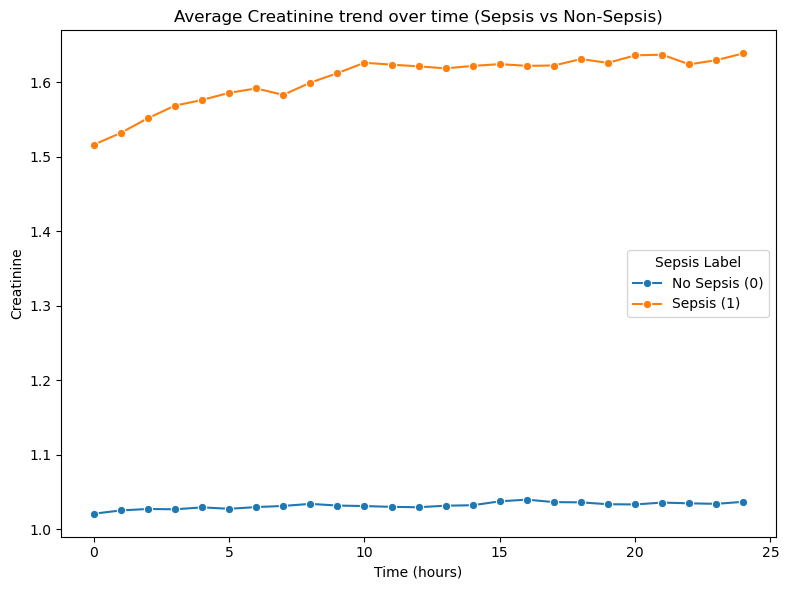

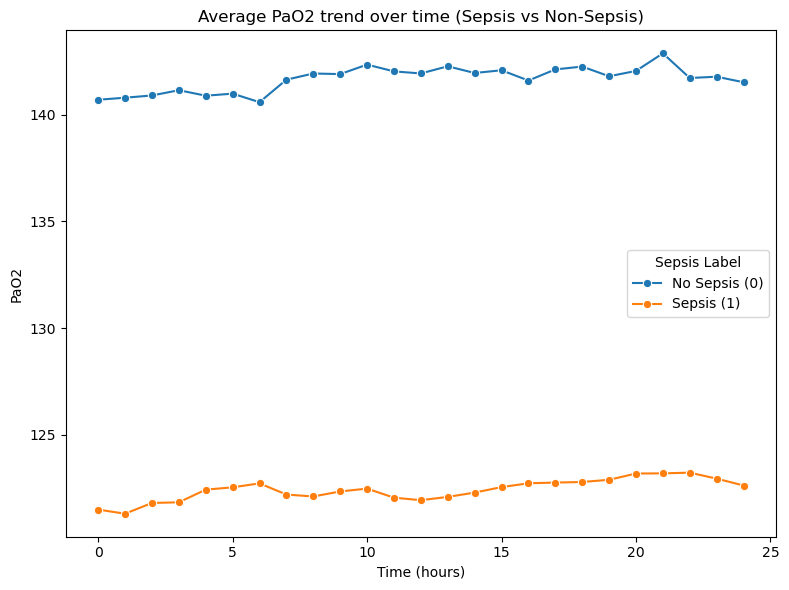

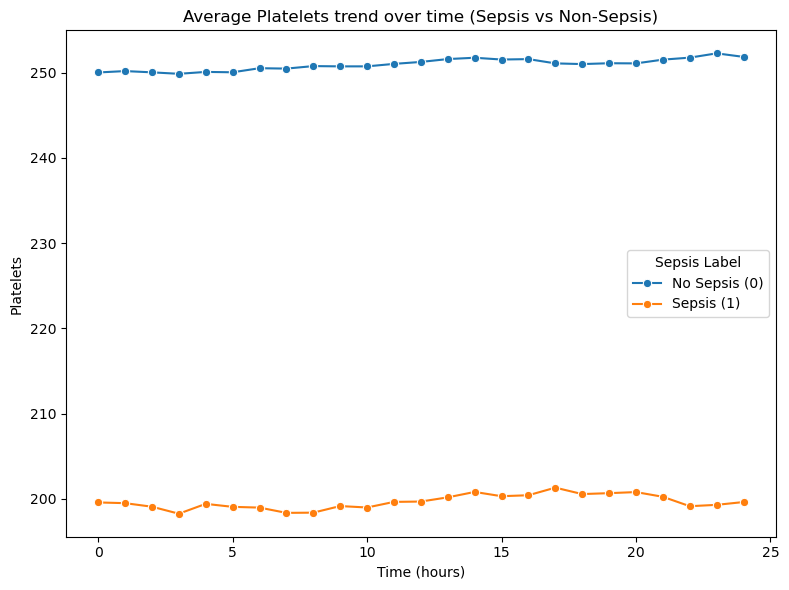

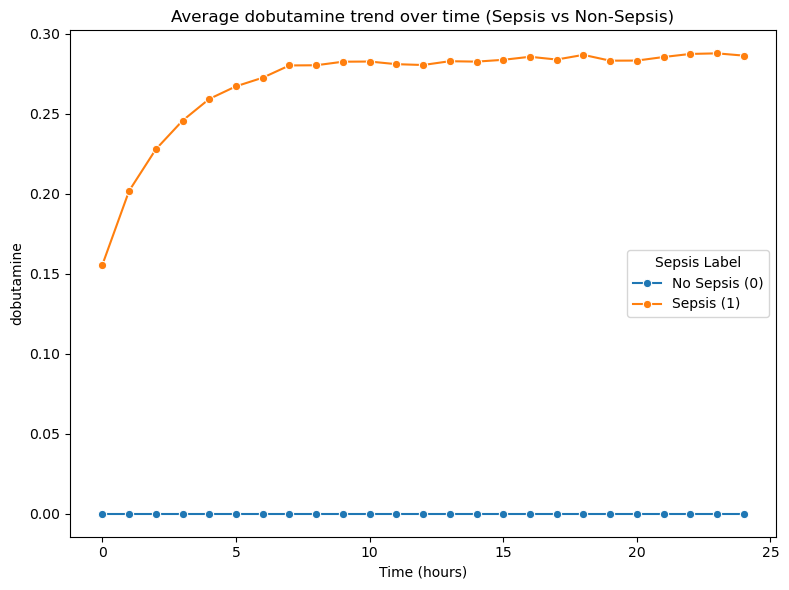

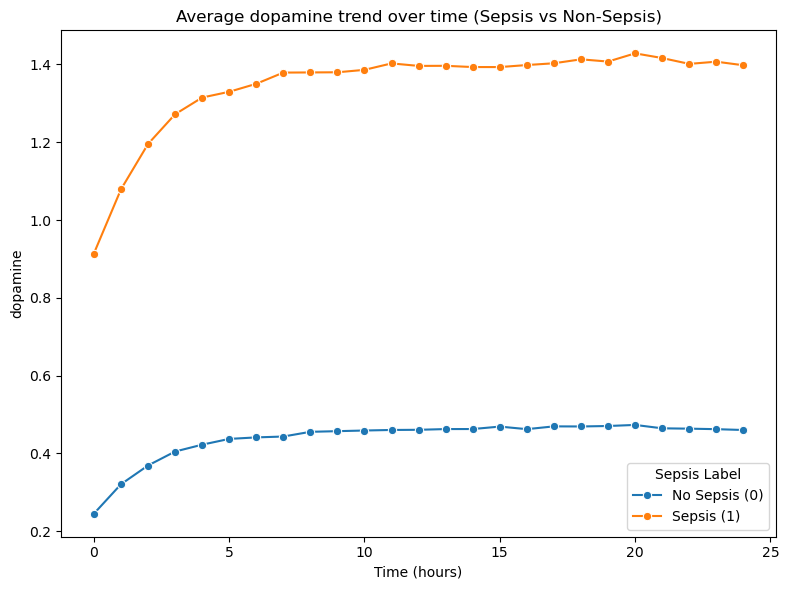

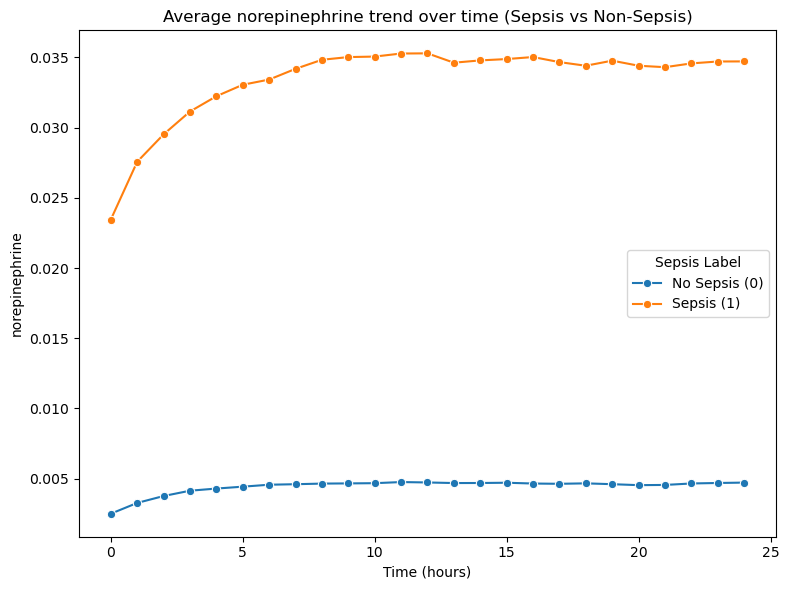

In [22]:
# 1.9 Feature trends over time (Sepsis(1) vs Non-Sepsis(0))
time_col = "hour"
# Select the main clinical features 
features = ["MAP", "FiO2", "GCS", "Bilirubin", "Creatinine",
            "PaO2", "Platelets", "dobutamine", "dopamine", "norepinephrine"]

# Map sepsis_label values to human-readable labels
label_map = {0: "No Sepsis (0)", 1: "Sepsis (1)"}

# Plot average trend over time for each feature
for f in features:
    avg_trend = (
        df.groupby([time_col, "sepsis_label"])[f]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(data=avg_trend, x=time_col, y=f, hue="sepsis_label", marker="o")
    plt.title(f"Average {f} trend over time (Sepsis vs Non-Sepsis)")
    plt.xlabel("Time (hours)")
    plt.ylabel(f)

    # Fix legend labels (convert 0 - No Sepsis, 1 -Sepsis)
    handles, labels = ax.get_legend_handles_labels()
    labels = [label_map[int(l)] for l in labels]
    plt.legend(handles, labels, title="Sepsis Label")
    plt.tight_layout()
    plt.show()

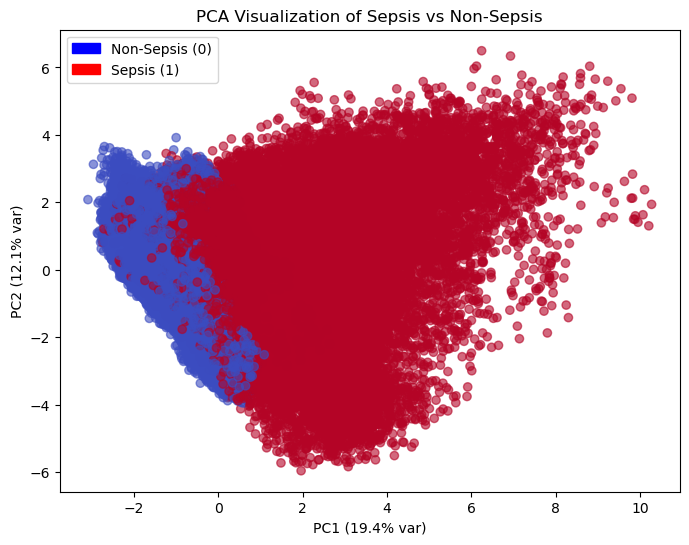

In [26]:
# 1.10 PCA Visualization

# Prepare feature set for PCA (exclude IDs and label)
pca_exclude = ['subject_id', 'icustay_id', 'sepsis_label', 'hour']
X_pca = df.drop(columns=[c for c in pca_exclude if c in df.columns]).select_dtypes(include=[np.number]).copy()
y_pca = df['sepsis_label'].copy()

# Standardize features (PCA works best with standardized data)
X_std = StandardScaler().fit_transform(X_pca.fillna(0))

# Apply PCA to reduce to 2D
pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X_std)

# Scatter plot of PCA components
plt.figure(figsize=(8,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=y_pca, cmap="coolwarm", alpha=0.6)

# Axis labels with explained variance
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Visualization of Sepsis vs Non-Sepsis")

# Custom legend for clarity
blue_patch = mpatches.Patch(color="blue", label="Non-Sepsis (0)")
red_patch = mpatches.Patch(color="red", label="Sepsis (1)")
plt.legend(handles=[blue_patch, red_patch], loc="best")
plt.show()

# 2.Data Preprocessing

In [29]:
# 2.1 Define Features and Labels
# 2.2 Train/Validation/Test Split (grouped by subject_id using GroupShuffleSplit)
# 2.3 Outlier Analysis and Treatment (IQR Clipping)

In [31]:
# 2.1 Define Features and Labels
# Exclude IDs and label column from features
exclude_cols = ['subject_id', 'icustay_id', 'hour', 'sepsis_label']
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Create feature matrix X and target vector y
X = df[feature_cols]
y = df['sepsis_label']
subjects = df['subject_id']  # Grouping variable for splitting

print("Selected feature columns:", feature_cols)

Selected feature columns: ['FiO2', 'GCS', 'MAP', 'Bilirubin', 'Creatinine', 'PaO2', 'Platelets', 'dobutamine', 'dopamine', 'norepinephrine', 'suspected_infection_flag']


In [33]:
# 2.2 Train/Validation/Test Split (grouped by subject_id)
# Prevents data leakage by ensuring each subject_id using GroupShuffleSplit
# appears in only one split
# First split: Development (80%) vs Test (20%)
# Second split: Train (70% of development set) vs Val (30% of development set)

# Grouping variable (Subject_id)
groups = subjects

# First split: Development (80%) vs Test (20%)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
dev_idx, test_idx = next(gss.split(X, y, groups=groups))

X_dev,  y_dev  = X.iloc[dev_idx],  y.iloc[dev_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
groups_dev     = groups.iloc[dev_idx]
groups_test    = groups.iloc[test_idx]

# Second split: Train (70% of development set) vs Val (30% of development set)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, val_idx = next(gss2.split(X_dev, y_dev, groups=groups_dev))

X_train, y_train = X_dev.iloc[train_idx], y_dev.iloc[train_idx]
X_val,   y_val   = X_dev.iloc[val_idx],  y_dev.iloc[val_idx]

# Sanity checks: no subject should appear in more than one split
train_subj = set(groups_dev.iloc[train_idx])
val_subj   = set(groups_dev.iloc[val_idx])
test_subj  = set(groups_test)

assert train_subj.isdisjoint(val_subj)
assert train_subj.isdisjoint(test_subj)
assert val_subj.isdisjoint(test_subj)

# Print results
print("Training set size    :", X_train.shape[0])
print("Validation set size  :", X_val.shape[0])
print("Testing set size     :", X_test.shape[0])

# No of unique patients in each splits
print("Training set:", len(train_subj), " Validation set:", len(val_subj), "Test set:", len(test_subj))

# check label distribution across splits
print("Sepsis label distribution (positive class rate):")
print("Train:", y_train.mean(), " Val:", y_val.mean(), " Test:", y_test.mean())


Training set size    : 140000
Validation set size  : 60000
Testing set size     : 50000
Training set: 5600  Validation set: 2400 Test set: 2000
Sepsis label distribution (positive class rate):
Train: 0.5064285714285715  Val: 0.49041666666666667  Test: 0.4935


Outlier counts per feature (train set):
dobutamine        15902
norepinephrine    14327
dopamine          10528
FiO2               8065
Creatinine         7622
PaO2               6484
MAP                6262
Bilirubin          5440
Platelets           907
dtype: int64
Outlier percentages per feature (train set):
dobutamine        11.36
norepinephrine    10.23
dopamine           7.52
FiO2               5.76
Creatinine         5.44
PaO2               4.63
MAP                4.47
Bilirubin          3.89
Platelets          0.65
dtype: float64
Clipped values per feature (train set):
dobutamine        15902
norepinephrine    14327
dopamine          10528
FiO2               8065
Creatinine         7622
PaO2               6484
MAP                6262
Bilirubin          5440
Platelets           907
dtype: int64


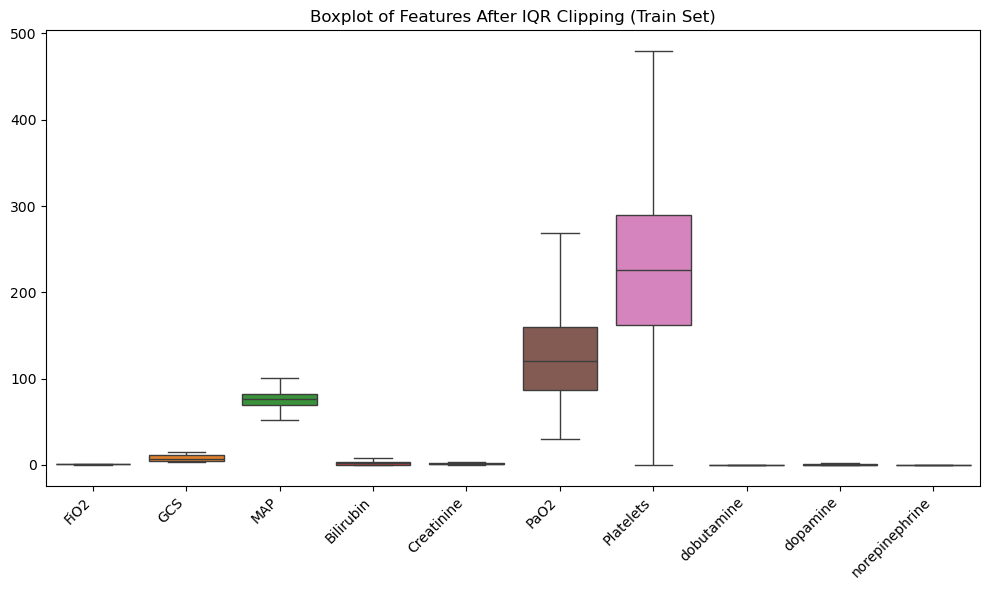

In [35]:
# 2.3 Outlier analysis and treatment (IQR Clipping)

# Work only on numeric features
numeric_features = X_train.select_dtypes(include=['number']).columns

# Compute IQR bounds on training set only
Q1   = X_train[numeric_features].quantile(0.25)
Q3   = X_train[numeric_features].quantile(0.75)
IQR  = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Outlier analysis 
outlier_mask = (X_train[numeric_features] < lower) | (X_train[numeric_features] > upper)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
outlier_percent = (outlier_counts / len(X_train) * 100).round(2)

print("Outlier counts per feature (train set):")
print(outlier_counts[outlier_counts > 0])
print("Outlier percentages per feature (train set):")
print(outlier_percent[outlier_percent > 0])

# Outlier Treatment (Clipping)
# Handle zero-IQR columns
zero_iqr_cols = IQR[IQR == 0].index
lower.loc[zero_iqr_cols] = float('-inf')
upper.loc[zero_iqr_cols] = float('inf')

def apply_iqr_clip(df_part, lower_bounds, upper_bounds, cols):
    df_out = df_part.copy()
    df_out[cols] = df_out[cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    return df_out

X_train_iqr = apply_iqr_clip(X_train, lower, upper, numeric_features)
X_val_iqr   = apply_iqr_clip(X_val,   lower, upper, numeric_features)
X_test_iqr  = apply_iqr_clip(X_test,  lower, upper, numeric_features)

# Check on how many values were clipped
clipped_counts = ((X_train[numeric_features] < lower) | (X_train[numeric_features] > upper)).sum()
print("Clipped values per feature (train set):")
print(clipped_counts[clipped_counts > 0].sort_values(ascending=False))

# Visualization after clipping
subset_features = numeric_features[:10]  
plt.figure(figsize=(10,6))
sns.boxplot(data=X_train_iqr[subset_features])
plt.title("Boxplot of Features After IQR Clipping (Train Set)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Feature Engineering

In [38]:
#3.1 Build static-patient level features for classical models (Logistic regression and XGBoost)
# 3.2 Build sequential tensors for deep learning models (LSTM and TCN)

In [40]:
#3.1 Build static-patient level features
# Configure column
# IDs, time and target
ID_COL    = "subject_id"
TIME_COL  = "hour"
LABEL_COL = "sepsis_label"

# base per-hour features present in data
FEATURES = [
    "FiO2", "GCS", "MAP", "Bilirubin", "Creatinine",
    "PaO2", "Platelets", "dobutamine", "dopamine",
    "norepinephrine"
]
def build_static_features(df: pd.DataFrame, id_col: str, time_col: str, label_col: str, feature_cols: list):
    df_sorted = df.sort_values([id_col, time_col]).copy()

    blocks = []
    for col in feature_cols:
        g = (
            df_sorted[[id_col, col]]
            .groupby(id_col, sort=False)[col]   # keep prior ordering
            .agg(['mean','std','min','max','first','last','count'])
            .rename(columns={
                'mean':f'{col}_mean','std':f'{col}_std','min':f'{col}_min','max':f'{col}_max',
                'first':f'{col}_first','last':f'{col}_last','count':f'{col}_count_obs'
            })
        )
        g[f'{col}_diff_last_first'] = g[f'{col}_last'] - g[f'{col}_first']
        blocks.append(g)

    X_static = pd.concat(blocks, axis=1)

    # Binary target per patient (any sepsis during stay)
    y_static = df_sorted.groupby(id_col, sort=False)[label_col].max()

    # Align indices 1:1
    X_static = X_static.loc[y_static.index]
    return X_static.astype('float32'), y_static.astype('int8')

X_static, y_static = build_static_features(df, ID_COL, TIME_COL, LABEL_COL, FEATURES)
print("X_static:", X_static.shape, " y:", y_static.value_counts().to_dict())

X_static: (10000, 80)  y: {1: 5000, 0: 5000}


In [42]:
# 3.2 Build sequential tensors
# Produces: X_seq, subjects_seq, feature_order, y_seq
def build_sequence_tensor(df: pd.DataFrame, id_col: str, time_col: str, label_col: str,
                          feature_cols: list, T_last: int = 24, ffill=True, bfill=True):
    # Ensure integer hour
    df2 = df.copy()
    df2[time_col] = df2[time_col].astype(int)

    hours = pd.Index(range(0, T_last + 1), name=time_col)
    wide_blocks = []

    for col in feature_cols:
        # pivot to subjects × hours for each feature
        w = (df2.pivot_table(index=id_col, columns=time_col, values=col, aggfunc="last")
               .reindex(columns=hours))

        if ffill:
            w = w.ffill(axis=1)   # carry forward within subject
        if bfill:
            w = w.bfill(axis=1)  

        # tag with feature name 
        w.columns = pd.MultiIndex.from_product([[col], w.columns], names=["feature", time_col])
        wide_blocks.append(w)

    # concat features along columns, keep feature order
    wide_all = pd.concat(wide_blocks, axis=1).sort_index(axis=1, level=0)

    subjects_seq = wide_all.index.to_numpy()
    feature_order = list(feature_cols)
    N, T, F = wide_all.shape[0], T_last + 1, len(feature_cols)

    # build tensor N×T×F in the feature order
    X_seq = np.empty((N, T, F), dtype=np.float32) # N: No of samples or patients, T: No of timesteps per sequence, F: No of features per timestep
    for j, col in enumerate(feature_cols):
        X_seq[:, :, j] = wide_all[col].to_numpy(dtype=float)

    # per-subject label 
    y_seq = (df2.groupby(id_col)[label_col].max()
               .reindex(subjects_seq).to_numpy(dtype=np.int8))

    return X_seq, subjects_seq, feature_order, y_seq

X_seq, subjects_seq, feature_order, y_seq = build_sequence_tensor(
    df, ID_COL, TIME_COL, LABEL_COL, FEATURES, T_last=24
)

N, T, F = X_seq.shape
print(f"N={N}, T={T}, F={F}, positives={int(y_seq.sum())}/{len(y_seq)}")
print("feature_order:", feature_order)

N=10000, T=25, F=10, positives=5000/10000
feature_order: ['FiO2', 'GCS', 'MAP', 'Bilirubin', 'Creatinine', 'PaO2', 'Platelets', 'dobutamine', 'dopamine', 'norepinephrine']


# 4. Feature Scaling

In [45]:
# Using MinMax scaling
# 4.1 Scaling for static features
# 4.2 Scaling for sequential features (for deep learning models)

In [47]:
# 4.1 Scale static features
# Split static features by subject sets
X_static_train = X_static.loc[list(train_subj)]
X_static_val   = X_static.loc[list(val_subj)]
X_static_test  = X_static.loc[list(test_subj)]

y_static_train = y_static.loc[list(train_subj)]
y_static_val   = y_static.loc[list(val_subj)]
y_static_test  = y_static.loc[list(test_subj)]

# Fit MinMaxScaler on training static features
scaler_static = MinMaxScaler(clip=True)
X_static_train_scaled = pd.DataFrame(
    scaler_static.fit_transform(X_static_train),
    columns=X_static.columns, index=X_static_train.index
)
X_static_val_scaled = pd.DataFrame(
    scaler_static.transform(X_static_val),
    columns=X_static.columns, index=X_static_val.index
)
X_static_test_scaled = pd.DataFrame(
    scaler_static.transform(X_static_test),
    columns=X_static.columns, index=X_static_test.index
)

print("Static features scaled:")
print("Train:", X_static_train_scaled.shape,
      " Val:", X_static_val_scaled.shape,
      " Test:", X_static_test_scaled.shape)

Static features scaled:
Train: (5600, 80)  Val: (2400, 80)  Test: (2000, 80)


In [49]:
# 4.2 Scale sequential features 

# Masks (align subjects to sequence tensor rows)
subjects_arr = np.asarray(subjects_seq)  # subject_id per row of X_seq

mask_train = np.isin(subjects_arr, list(train_subj))
mask_val   = np.isin(subjects_arr, list(val_subj))
mask_test  = np.isin(subjects_arr, list(test_subj))

# Split tensors
X_seq_train = X_seq[mask_train]
X_seq_val   = X_seq[mask_val]
X_seq_test  = X_seq[mask_test]

y_seq_train = y_seq[mask_train]
y_seq_val   = y_seq[mask_val]
y_seq_test  = y_seq[mask_test]

# Scale each feature across all timesteps 
N_train, T, F = X_seq_train.shape
scaler_seq = [MinMaxScaler(clip=True) for _ in range(F)]

X_seq_train_scaled = np.empty_like(X_seq_train, dtype=float)
X_seq_val_scaled   = np.empty_like(X_seq_val,   dtype=float)
X_seq_test_scaled  = np.empty_like(X_seq_test,  dtype=float)

for j in range(F):
    # flatten feature across patients and time for scaling
    train_flat = X_seq_train[:, :, j].reshape(-1, 1)
    scaler_seq[j].fit(train_flat)

    X_seq_train_scaled[:, :, j] = scaler_seq[j].transform(train_flat).reshape(N_train, T)
    X_seq_val_scaled[:, :, j]   = scaler_seq[j].transform(X_seq_val[:, :, j].reshape(-1, 1)).reshape(X_seq_val.shape[0], T)
    X_seq_test_scaled[:, :, j]  = scaler_seq[j].transform(X_seq_test[:, :, j].reshape(-1, 1)).reshape(X_seq_test.shape[0], T)

print("Sequential features scaled:")
print("Train:", X_seq_train_scaled.shape,
      " Val:",  X_seq_val_scaled.shape,
      " Test:", X_seq_test_scaled.shape)


Sequential features scaled:
Train: (5600, 25, 10)  Val: (2400, 25, 10)  Test: (2000, 25, 10)


# 5. Model fitting

### Logistic Regression

Validation — Accuracy: 0.9996  Precision: 1.0000  Recall: 0.9992  F1-Score: 0.9996  AUROC: 1.0000


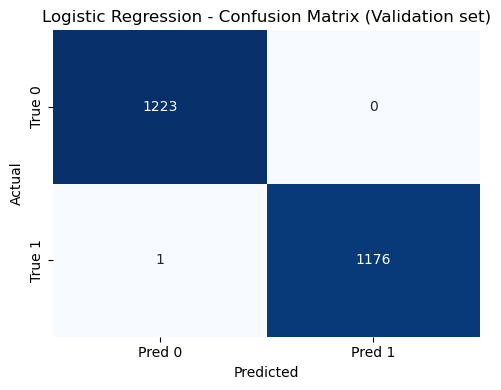

In [53]:
# LR - train and validate

# Build a leakage-safe feature set
# Align label to X_static index
y_all = y_static.loc[X_static.index].values

# Drop features that are likely label proxies
drop_cols = set([c for c in X_static.columns
                 if ("sepsis" in c.lower()) or ("suspected_infection" in c.lower())])

# Drop columns exactly equal to the label 
drop_cols |= set([c for c in X_static.columns if np.array_equal(X_static[c].values, y_all)])

# Drop single features with AUROC 1 or 0 (near-perfect proxies)
from sklearn.metrics import roc_auc_score as _auc
for c in X_static.columns:
    x = X_static[c].values
    if np.nanstd(x) == 0:
        drop_cols.add(c)
        continue
    try:
        a = _auc(y_all, x)
        if (a >= 0.995) or (a <= 0.005):
            drop_cols.add(c)
    except Exception:
        pass

X_static_clean = X_static.drop(columns=list(drop_cols), errors="ignore")

# Select existing train/validation subjects
Xtr_df = X_static_clean.loc[list(train_subj)]
Xva_df = X_static_clean.loc[list(val_subj)]

ytr = y_static.loc[list(train_subj)].values
yva = y_static.loc[list(val_subj)].values

Xtr = Xtr_df.values
Xva = Xva_df.values

# Scale (fit on trainning set only and transform validation set)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xva_s = scaler.transform(Xva)

# Train Logistic Regression
lr = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=5000,
    random_state=SEED
)
lr.fit(Xtr_s, ytr)

# Validation probabilities & AUROC
val_proba = lr.predict_proba(Xva_s)[:, 1]
val_auroc = roc_auc_score(yva, val_proba)

# Validation Accuracy & Precision at 0.5 threshold
# Threshold fixed at 0.5 since it is the standard default in sklearn classifiers and for giving a neutral trade-off & consistent across models
val_pred = (val_proba >= 0.5).astype(int) 
val_acc  = accuracy_score(yva, val_pred)
val_prec = precision_score(yva, val_pred, zero_division=0)
val_auroc = roc_auc_score(yva, val_proba)
val_recall = recall_score(yva, val_pred, zero_division=0)
val_f1    = f1_score(yva, val_pred, zero_division=0)

print(f"Validation — Accuracy: {val_acc:.4f}  "
      f"Precision: {val_prec:.4f}  "
      f"Recall: {val_recall:.4f}  "
      f"F1-Score: {val_f1:.4f}  "
      f"AUROC: {val_auroc:.4f}")

# Confusion matrix for validation set
cm = confusion_matrix(yva, val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("Logistic Regression - Confusion Matrix (Validation set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Test set  Accuracy: 0.9990  Precision: 1.0000  Recall: 0.9980  F1: 0.9990  AUROC: 1.0000


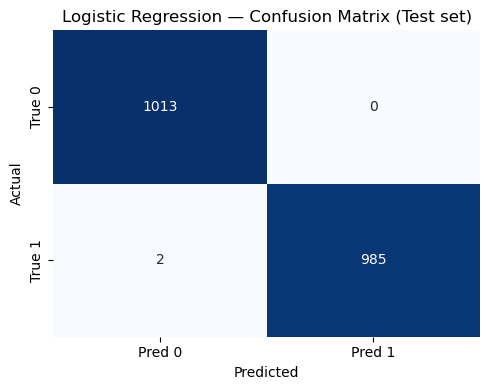

In [55]:
# Test set evaluation for LR
cols_lr = Xtr_df.columns.tolist()

# Build test matrices with the same columns
Xte_df = X_static_clean.loc[list(test_subj), cols_lr]
yte    = y_static.loc[list(test_subj)].values

# Transform with the same scaler fitted on training
Xte_s  = scaler.transform(Xte_df.values)

# Predict probabilities and labels at threshold=0.5
te_proba = lr.predict_proba(Xte_s)[:, 1]
te_pred  = (te_proba >= 0.5).astype(int)

# Metrics
te_acc   = accuracy_score(yte, te_pred)
te_prec  = precision_score(yte, te_pred, zero_division=0)
te_rec   = recall_score(yte, te_pred, zero_division=0)
te_f1    = f1_score(yte, te_pred, zero_division=0)
te_auroc = roc_auc_score(yte, te_proba)

print(f"Test set  "
      f"Accuracy: {te_acc:.4f}  Precision: {te_prec:.4f}  "
      f"Recall: {te_rec:.4f}  F1: {te_f1:.4f}  AUROC: {te_auroc:.4f}")

# Confusion matrix for test set
cm = confusion_matrix(yte, te_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("Logistic Regression — Confusion Matrix (Test set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### XGBoost

Validation — Accuracy: 0.9996  Precision: 1.0000  Recall: 0.9992  F1-Score: 0.9996  AUROC: 1.0000


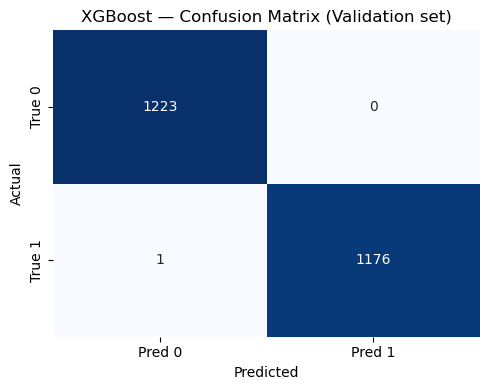

In [58]:
#XGBoost- train & validate

# Build a leakage-safe feature set
# Align label to X_static index
y_all = y_static.loc[X_static.index].values

# Drop features that likely proxy the label
drop_cols = set([c for c in X_static.columns
                 if ("sepsis" in c.lower()) or ("suspected_infection" in c.lower())])

# Drop columns excatly equal to the label
drop_cols |= set([c for c in X_static.columns if np.array_equal(X_static[c].values, y_all)])

# Drop single features with AUROC 1 or 0 (near-perfect proxies)
for c in X_static.columns:
    x = X_static[c].values
    if np.nanstd(x) == 0:
        continue
    try:
        auc_single = roc_auc_score(y_all, x)
        if (auc_single >= 0.995) or (auc_single <= 0.005):
            drop_cols.add(c)
    except Exception:
        pass

X_static_clean = X_static.drop(columns=list(drop_cols), errors="ignore")

# Subject-wise splits
Xtr_df = X_static_clean.loc[list(train_subj)]
Xva_df = X_static_clean.loc[list(val_subj)]

ytr = y_static.loc[list(train_subj)].values
yva = y_static.loc[list(val_subj)].values

# Class imbalance handling
pos = int((ytr == 1).sum()); neg = int((ytr == 0).sum())
spw = (neg / pos) if pos > 0 else 1.0 

# Train XGBoost
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
    scale_pos_weight=spw
)
xgb_clf.fit(Xtr_df, ytr)

# Validation metrics
val_proba = xgb_clf.predict_proba(Xva_df)[:, 1]
val_auroc = roc_auc_score(yva, val_proba)

# Accuracy & Precision at fixed 0.5 threshold
val_pred = (val_proba >= 0.5).astype(int)
val_acc  = accuracy_score(yva, val_pred)
val_prec = precision_score(yva, val_pred, zero_division=0)
val_recall = recall_score(yva, val_pred, zero_division=0)
val_f1     = f1_score(yva, val_pred, zero_division=0)

print(f"Validation — Accuracy: {val_acc:.4f}  "
      f"Precision: {val_prec:.4f}  "
      f"Recall: {val_recall:.4f}  "
      f"F1-Score: {val_f1:.4f}  "
      f"AUROC: {val_auroc:.4f}")

# Confusion Matrix for validation set
cm = confusion_matrix(yva, val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("XGBoost — Confusion Matrix (Validation set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Test set Accuracy: 0.9980  Precision: 0.9980  Recall: 0.9980  F1: 0.9980  AUROC: 1.0000


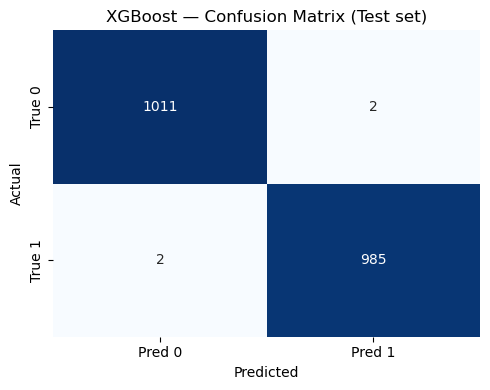

In [60]:
# Test set evaluation for XGBoost
cols_xgb = Xtr_df.columns.tolist()

# Build test matrices with same columns
Xte_df = X_static_clean.loc[list(test_subj), cols_xgb]
yte    = y_static.loc[list(test_subj)].values

# Predict probabilities and labels
te_proba = xgb_clf.predict_proba(Xte_df.values)[:, 1]
te_pred  = (te_proba >= 0.5).astype(int)

# Metrics
te_acc   = accuracy_score(yte, te_pred)
te_prec  = precision_score(yte, te_pred, zero_division=0)
te_rec   = recall_score(yte, te_pred, zero_division=0)
te_f1    = f1_score(yte, te_pred, zero_division=0)
te_auroc = roc_auc_score(yte, te_proba)

print(f"Test set "
      f"Accuracy: {te_acc:.4f}  Precision: {te_prec:.4f}  "
      f"Recall: {te_rec:.4f}  F1: {te_f1:.4f}  AUROC: {te_auroc:.4f}")

# Confusion Matrix for test set
cm = confusion_matrix(yte, te_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("XGBoost — Confusion Matrix (Test set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### TCN -Temporal Convolutional Network

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - AUC: 0.6410 - loss: 3.4122 - val_AUC: 0.8923 - val_loss: 0.4294 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - AUC: 0.9244 - loss: 0.3493 - val_AUC: 0.8121 - val_loss: 2.5260 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - AUC: 0.9729 - loss: 0.2102 - val_AUC: 0.9782 - val_loss: 1.1416 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - AUC: 0.9874 - loss: 0.1452 - val_AUC: 0.9944 - val_loss: 0.2743 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - AUC: 0.9935 - loss: 0.1026 - val_AUC: 0.9940 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - AUC: 0.9955 - loss: 0.0835 - val_AUC: 0.9978 - val_loss: 0.1554 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - AUC: 0.9971 - loss: 0.0690 - val_AUC: 0.9963 - val_loss: 0.2912 - learning_rate: 0.0010
Epoch 8/50
8

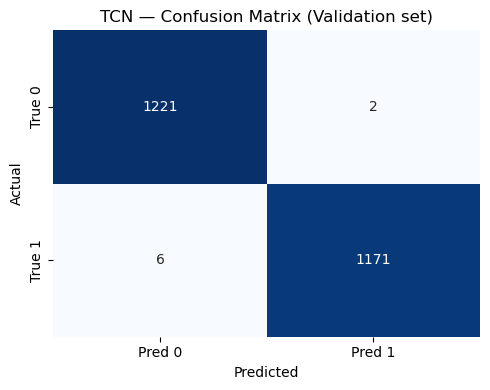

In [63]:
# TCN — train and validate
warnings.filterwarnings("ignore")

# Subject-wise splits
subjects = np.asarray(subjects_seq)
train_mask = np.isin(subjects, list(train_subj))
val_mask   = np.isin(subjects, list(val_subj))

X_seq_tr, y_seq_tr = X_seq[train_mask], y_seq[train_mask]
X_seq_va, y_seq_va = X_seq[val_mask],  y_seq[val_mask]
 
X_seq_tr_f = np.nan_to_num(X_seq_tr, nan=0.0).astype("float32")
X_seq_va_f = np.nan_to_num(X_seq_va, nan=0.0).astype("float32")
T, F = X_seq_tr_f.shape[1], X_seq_tr_f.shape[2]

# Define TCN
def residual_block(x, filters, kernel_size, dilation_rate, dropout):
    y = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation_rate)(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation_rate)(y)
    y = layers.BatchNormalization()(y)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)  
    return layers.ReLU()(layers.Add()([x, y]))

def build_tcn(T, F, filters=64, kernel_size=3, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=(T, F))
    x = layers.Masking(mask_value=0.0)(inp)
    x = residual_block(x, filters, kernel_size, dilation_rate=1, dropout=dropout)
    x = residual_block(x, filters, kernel_size, dilation_rate=2, dropout=dropout)
    x = residual_block(x, filters, kernel_size, dilation_rate=4, dropout=dropout)
    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = models.Model(inp, out)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[metrics.AUC(name="AUC")]
    )
    return m

tcn_model = build_tcn(T, F, filters=64, kernel_size=3, dropout=0.2, lr=1e-3)

# Class weights & callbacks
pos = int((y_seq_tr == 1).sum()); neg = int((y_seq_tr == 0).sum())
class_weights = {0: 1.0, 1: (neg / max(pos, 1))}

es  = callbacks.EarlyStopping(monitor="val_AUC", mode="max",
                              patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_AUC", mode="max",
                                  factor=0.5, patience=4, min_lr=1e-6, verbose=1)

# Train TCN
history_tcn = tcn_model.fit(
    X_seq_tr_f, y_seq_tr,
    validation_data=(X_seq_va_f, y_seq_va),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[es, rlr],
    verbose=1
)

# Validation metrics at threshold=0.5
# The final Dense layer uses sigmoid activation (outputs probability 0–1). So, apply threshold = 0.5 (standard default) to convert probabilities into binary predictions, ensuring consistency with classical models (LR and XGBoost).
val_proba = tcn_model.predict(X_seq_va_f, verbose=0).ravel()
val_pred  = (val_proba >= 0.5).astype(int)

val_auroc = roc_auc_score(y_seq_va, val_proba)
val_acc   = accuracy_score(y_seq_va, val_pred)
val_prec  = precision_score(y_seq_va, val_pred, zero_division=0)
val_recall = recall_score(y_seq_va, val_pred, zero_division=0)
val_f1     = f1_score(y_seq_va, val_pred, zero_division=0)

print(f" Validation - Accuracy: {val_acc:.4f}  "
      f"Precision: {val_prec:.4f}  "
      f"Recall: {val_recall:.4f}  "
      f"F1-Score: {val_f1:.4f}  "
      f"AUROC: {val_auroc:.4f}")

# Confusion matrix for validation set
cm = confusion_matrix(y_seq_va, val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("TCN — Confusion Matrix (Validation set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout() 
plt.show()


Test Set - Accuracy: 0.9945  Precision: 0.9939  Recall: 0.9949  F1-Score: 0.9944  AUROC: 1.0000


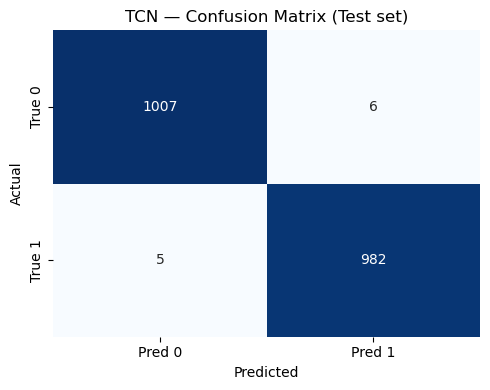

In [71]:
# TCN — Test set evaluation

# Subject-wise test split 
mask_test = np.isin(subjects, list(test_subj))  
X_seq_te  = X_seq[mask_test]
y_seq_te  = y_seq[mask_test]

X_seq_te_f = np.nan_to_num(X_seq_te, nan=0.0).astype("float32")

# Predict probabilities with the trained TCN
te_proba = tcn_model.predict(X_seq_te_f, verbose=0).ravel()
te_pred  = (te_proba >= 0.5).astype(int)

# Evaluation metrics 
te_auroc = roc_auc_score(y_seq_te, te_proba)
te_acc   = accuracy_score(y_seq_te, te_pred)
te_prec  = precision_score(y_seq_te, te_pred, zero_division=0)
te_recall = recall_score(y_seq_te, te_pred, zero_division=0)
te_f1     = f1_score(y_seq_te, te_pred, zero_division=0)

print(f"Test Set - Accuracy: {te_acc:.4f}  "
      f"Precision: {te_prec:.4f}  "
      f"Recall: {te_recall:.4f}  "
      f"F1-Score: {te_f1:.4f}  "
      f"AUROC: {te_auroc:.4f}")

# Confusion matrix for test set
cm = confusion_matrix(y_seq_te, te_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title("TCN — Confusion Matrix (Test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### LSTM- Long Short-Term Memory algorithm

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - AUC: 0.6240 - loss: 0.6541 - val_AUC: 0.7956 - val_loss: 0.5360 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - AUC: 0.7619 - loss: 0.5454 - val_AUC: 0.8550 - val_loss: 0.4788 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - AUC: 0.8003 - loss: 0.5037 - val_AUC: 0.9021 - val_loss: 0.4298 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - AUC: 0.8609 - loss: 0.4491 - val_AUC: 0.9265 - val_loss: 0.3684 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - AUC: 0.8994 - loss: 0.3940 - val_AUC: 0.9567 - val_loss: 0.3301 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - AUC: 0.9351 - loss: 0.3359 - val_AUC: 0.9629 - val_loss: 0.2739 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - AUC: 0.9418 - loss: 0.3067 - val_AUC: 0.9728 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 8/50
8

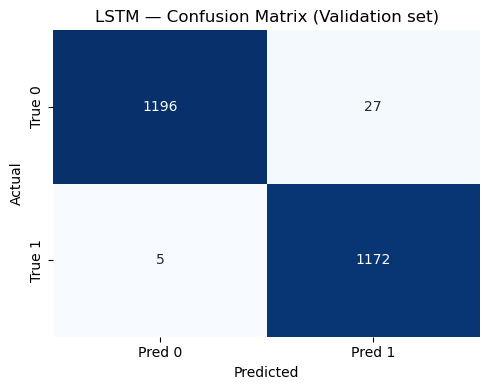

In [93]:
# LSTM — train and validate

# Subject-wise splits
subjects = np.asarray(subjects_seq)
train_mask = np.isin(subjects, list(train_subj))
val_mask   = np.isin(subjects, list(val_subj))

X_seq_tr, y_seq_tr = X_seq[train_mask], y_seq[train_mask]
X_seq_va, y_seq_va = X_seq[val_mask],  y_seq[val_mask]

X_seq_tr_f = np.nan_to_num(X_seq_tr, nan=0.0).astype("float32")
X_seq_va_f = np.nan_to_num(X_seq_va, nan=0.0).astype("float32")
T, F = X_seq_tr_f.shape[1], X_seq_tr_f.shape[2]

# Define LSTM
def build_lstm(T, F, units=64, dropout=0.3, lr=1e-3):
    inp = layers.Input(shape=(T, F))
    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.LSTM(units, return_sequences=False)(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = models.Model(inp, out)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[metrics.AUC(name="AUC")]
    )
    return m

lstm_model = build_lstm(T, F, units=64, dropout=0.3, lr=1e-3)

# Class weights & callbacks
pos = int((y_seq_tr == 1).sum()); neg = int((y_seq_tr == 0).sum())
class_weights = {0: 1.0, 1: (neg / max(pos, 1))}

es  = callbacks.EarlyStopping(monitor="val_AUC", mode="max",
                              patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_AUC", mode="max",
                                  factor=0.5, patience=4, min_lr=1e-6, verbose=1)

# Train LSTM
history_lstm = lstm_model.fit(
    X_seq_tr_f, y_seq_tr,
    validation_data=(X_seq_va_f, y_seq_va),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[es, rlr],
    verbose=1
)

# Validation metrics at threshold=0.5
# Apply threshold = 0.5 (standard default) to convert probabilities into binary predictions for consistency .
val_proba = lstm_model.predict(X_seq_va_f, verbose=0).ravel()
val_pred  = (val_proba >= 0.5).astype(int)

val_auroc = roc_auc_score(y_seq_va, val_proba)
val_acc   = accuracy_score(y_seq_va, val_pred)
val_prec  = precision_score(y_seq_va, val_pred, zero_division=0)
val_recall = recall_score(y_seq_va, val_pred, zero_division=0)
val_f1     = f1_score(y_seq_va, val_pred, zero_division=0)

print(f" Validation - Accuracy: {val_acc:.4f}  "
      f"Precision: {val_prec:.4f}  "
      f"Recall: {val_recall:.4f}  "
      f"F1-Score: {val_f1:.4f}  "
      f"AUROC: {val_auroc:.4f}")

# Confusion matrix for validation set
cm = confusion_matrix(y_seq_va, val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("LSTM — Confusion Matrix (Validation set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Test Set - Accuracy: 0.9860  Precision: 0.9781  Recall: 0.9939  F1-Score: 0.9859  AUROC: 0.9996


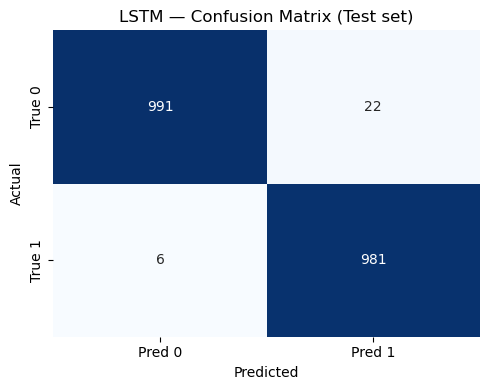

In [95]:
# LSTM — Test set evaluation

# Subject-wise test set split
mask_test = np.isin(subjects, list(test_subj))  
X_seq_te  = X_seq[mask_test]
y_seq_te  = y_seq[mask_test]

X_seq_te_f = np.nan_to_num(X_seq_te, nan=0.0).astype("float32")

# Predict probabilities with the trained LSTM
te_proba = lstm_model.predict(X_seq_te_f, verbose=0).ravel()
te_pred  = (te_proba >= 0.5).astype(int)

# Evaluation Metrics 
te_auroc = roc_auc_score(y_seq_te, te_proba)
te_acc   = accuracy_score(y_seq_te, te_pred)
te_prec  = precision_score(y_seq_te, te_pred, zero_division=0)
te_recall = recall_score(y_seq_te, te_pred, zero_division=0)
te_f1     = f1_score(y_seq_te, te_pred, zero_division=0)

print(f"Test Set - Accuracy: {te_acc:.4f}  "
      f"Precision: {te_prec:.4f}  "
      f"Recall: {te_recall:.4f}  "
      f"F1-Score: {te_f1:.4f}  "
      f"AUROC: {te_auroc:.4f}")

# Confusion matrix for test set
cm = confusion_matrix(y_seq_te, te_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title("LSTM — Confusion Matrix (Test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

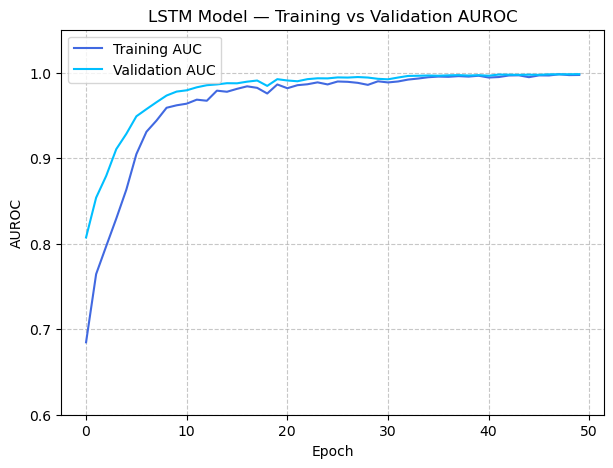

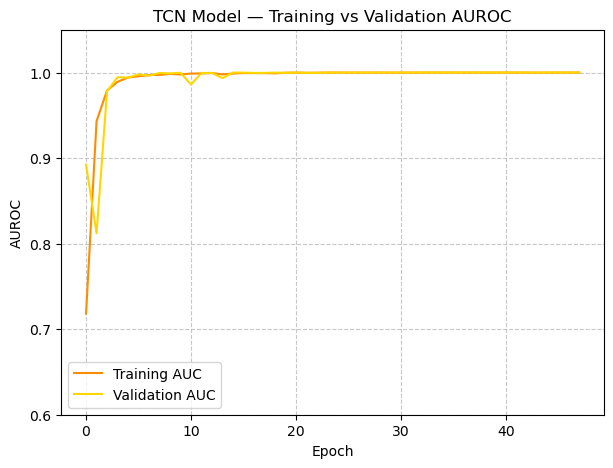

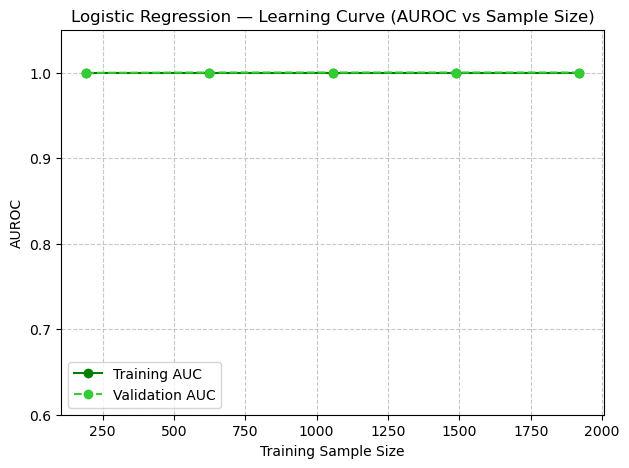

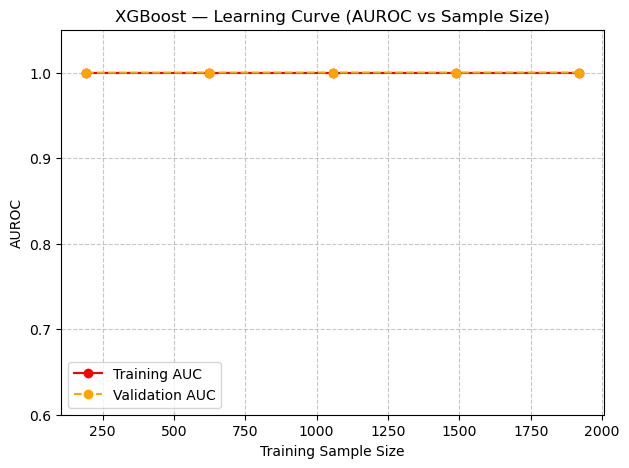

In [77]:
# Performance evaluation - Tranning vs Validation AUROC
# LSTM Model
plt.figure(figsize=(7,5))
plt.plot(history_lstm.history['AUC'], color='royalblue', label='Training AUC')
plt.plot(history_lstm.history['val_AUC'], color='deepskyblue', label='Validation AUC')
plt.title('LSTM Model — Training vs Validation AUROC')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# TCN Model
plt.figure(figsize=(7,5))
plt.plot(history_tcn.history['AUC'], color='darkorange', label='Training AUC')
plt.plot(history_tcn.history['val_AUC'], color='gold', label='Validation AUC')
plt.title('TCN Model — Training vs Validation AUROC')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Logistic Regression
train_sizes, train_scores, val_scores = learning_curve(lr, Xva_s, yva, cv=5, scoring='roc_auc', n_jobs=-1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Training AUC')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o--', color='limegreen', label='Validation AUC')
plt.title('Logistic Regression — Learning Curve (AUROC vs Sample Size)')
plt.xlabel('Training Sample Size')
plt.ylabel('AUROC')
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# XGBoost
train_sizes, train_scores, val_scores = learning_curve(xgb_clf, Xva_df, yva, cv=5, scoring='roc_auc', n_jobs=-1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='red', label='Training AUC')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o--', color='orange', label='Validation AUC')
plt.title('XGBoost — Learning Curve (AUROC vs Sample Size)')
plt.xlabel('Training Sample Size')
plt.ylabel('AUROC')
plt.ylim(0.6, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


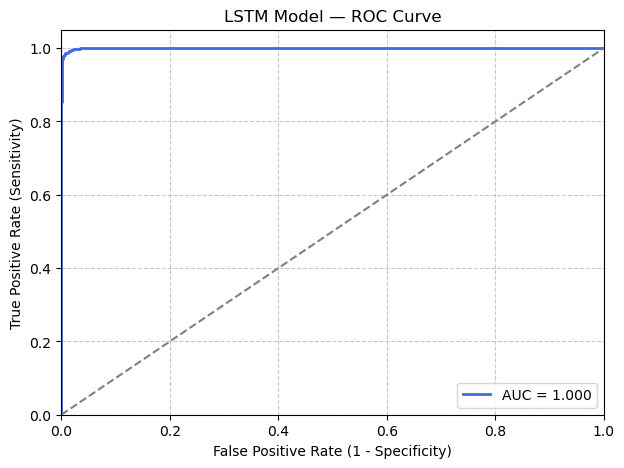

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


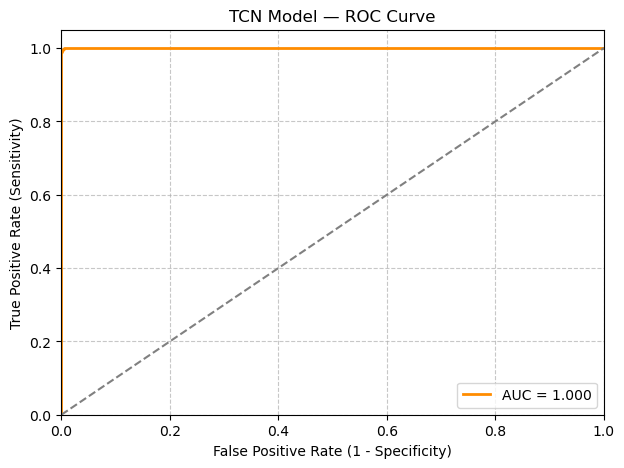

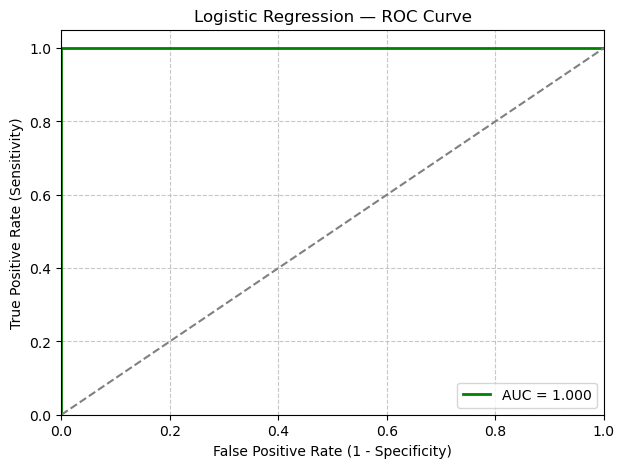

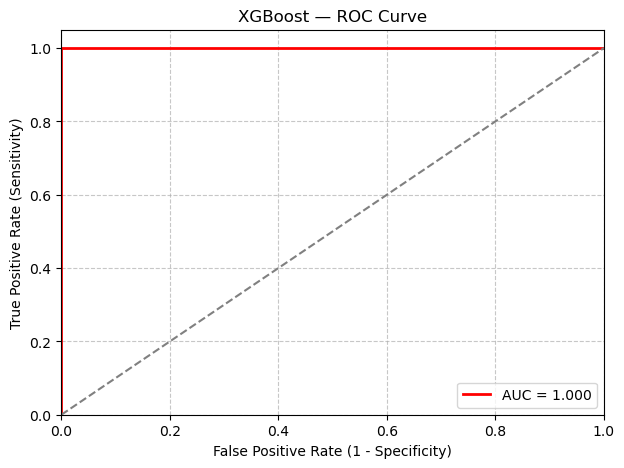

In [97]:
# ROC validation: True Positive Rate vs False Positive Rate with AUROC
# LSTM Model
y_pred_lstm = lstm_model.predict(X_seq_va_f).ravel()
fpr_lstm, tpr_lstm, _ = roc_curve(y_seq_va, y_pred_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(7,5))
plt.plot(fpr_lstm, tpr_lstm, color='royalblue', lw=2, label=f'AUC = {roc_auc_lstm:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('LSTM Model — ROC Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# TCN Model
y_pred_tcn = tcn_model.predict(X_seq_va_f).ravel()
fpr_tcn, tpr_tcn, _ = roc_curve(y_seq_va, y_pred_tcn)
roc_auc_tcn = auc(fpr_tcn, tpr_tcn)

plt.figure(figsize=(7,5))
plt.plot(fpr_tcn, tpr_tcn, color='darkorange', lw=2, label=f'AUC = {roc_auc_tcn:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('TCN Model — ROC Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Logistic Regression
y_pred_lr = lr.predict_proba(Xva_s)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(yva, y_pred_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'AUC = {roc_auc_lr:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Logistic Regression — ROC Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# XGBoost
y_pred_xgb = xgb_clf.predict_proba(Xva_df)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(yva, y_pred_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'AUC = {roc_auc_xgb:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('XGBoost — ROC Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# 6.Validation using SHAP
#### Purpose: illustrate model explanations on final predictions

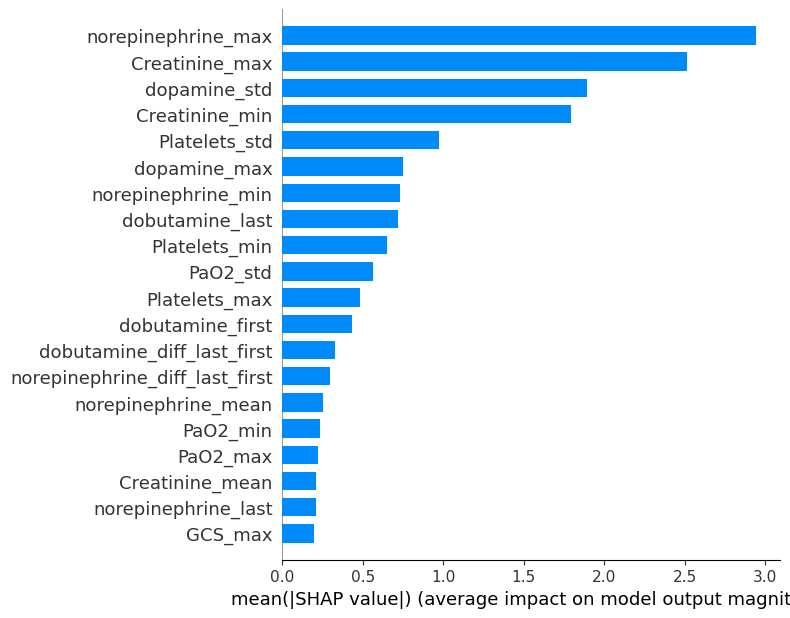

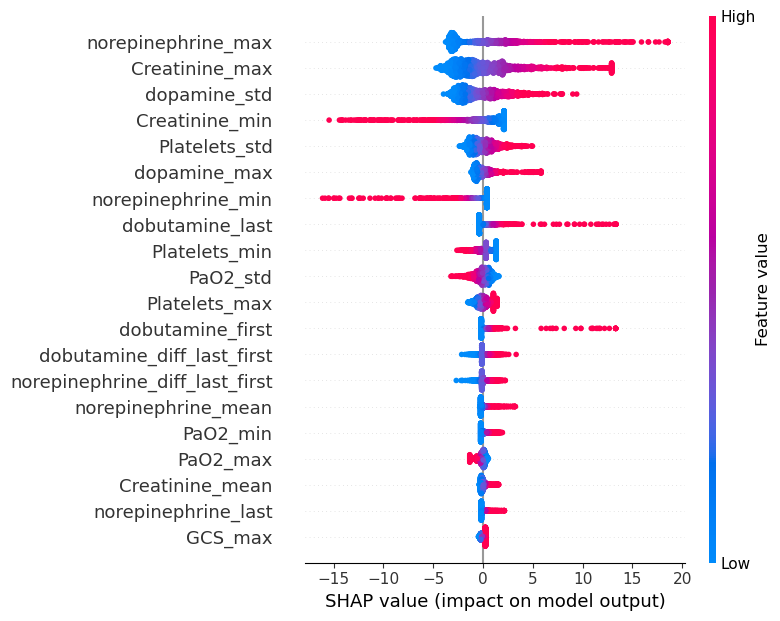

In [89]:
# SHAP for Logistic regression
import shap
# Scale while preserving column names
scaler = StandardScaler()
Xtr_s_df = pd.DataFrame(scaler.fit_transform(Xtr_df), columns=Xtr_df.columns, index=Xtr_df.index)
Xte_s_df = pd.DataFrame(scaler.transform(Xte_df), columns=Xte_df.columns, index=Xte_df.index)

# Fit a fresh LR on the named, scaled dataframes
lr_named = LogisticRegression(max_iter=1000, n_jobs=-1, solver="lbfgs")
lr_named.fit(Xtr_s_df, ytr)

# SHAP explainer and visualization
explainer = shap.LinearExplainer(lr_named, Xtr_s_df)  
sv = explainer(Xte_s_df)

# Global importance (bar plot) 
shap.summary_plot(sv, Xte_s_df, plot_type="bar", show=False)
plt.gcf().set_size_inches(8, 6)
plt.savefig("shap_lr_named_test_bar.png", dpi=300, bbox_inches="tight") 
plt.show()

# Beeswarm distribution plot 
shap.summary_plot(sv, Xte_s_df, show=False)
plt.gcf().set_size_inches(8, 6)
plt.savefig("shap_lr_named_test_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

 98%|===================| 1951/2000 [00:20<00:00]        

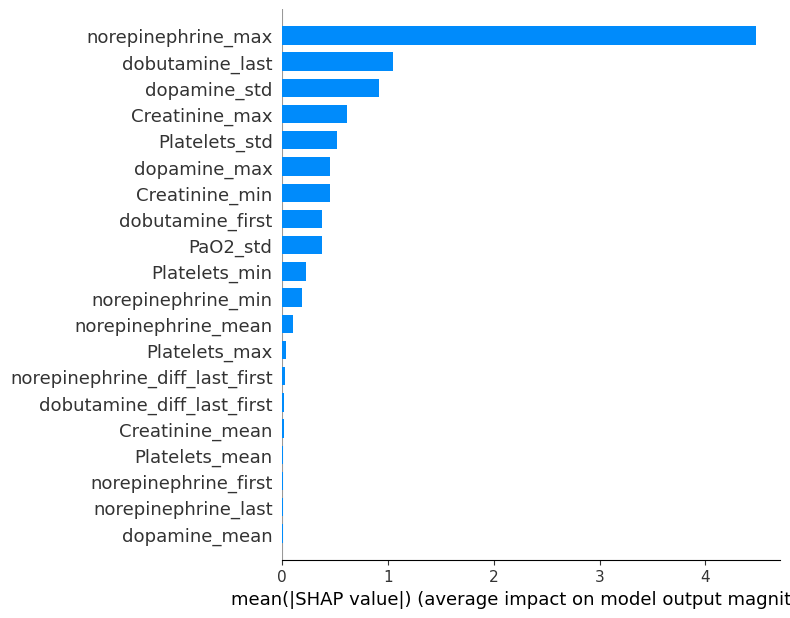

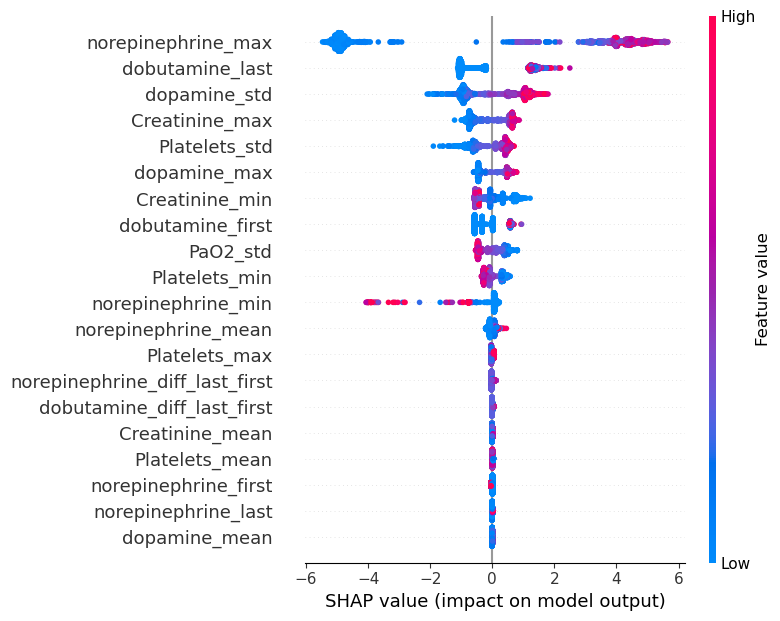

In [90]:
# SHAP for XGBoost  
# Background: small sample from training dataset 
background = Xtr_df.sample(n=min(100, len(Xtr_df)), random_state=SEED)

# Optimized explainer for tree-based models
explainer = shap.TreeExplainer(xgb_clf, data=background)

# Explain test set 
X_shap = Xte_df.copy()

# Compute SHAP values 
shap_values = explainer(X_shap, check_additivity=False)

# Global importance (bar plot) 
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.gcf().set_size_inches(8, 6)   
plt.savefig("shap_xgb_test_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm distribution plot 
shap.summary_plot(shap_values, X_shap, show=False)
plt.gcf().set_size_inches(8, 6)   
plt.savefig("shap_xgb_test_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()